# 🇹🇷 Türkiye Yatırım Araçları — Çok Dönemli Performans Analizi

**Yazar:** Burak | Veri Bilimcisi & Analist  
**Kapsam:** 1 Ay · 1 Yıl · 5 Yıl · 10 Yıl  
**Araçlar:** Python · yfinance · pandas · matplotlib · seaborn

---

## 🎯 Bu Proje Ne Soruyor?

Türkiye, dünyanın en karmaşık yatırım ortamlarından birine sahip:
- Üç haneli enflasyon
- Kur kaybı
- Nominal olarak güçlü görünen ama reel olarak eriyen getiriler

Bu analiz şu soruları yanıtlıyor:

1. Hangi yatırım araçları **enflasyonu gerçekten yendi?**
2. Her aracın **reel (enflasyona göre düzeltilmiş) getirisi** ne?
3. Türk yatırımcı için **risk/getiri dengesi** nasıl görünüyor?
4. Hangi araçlar **birlikte hareket ediyor**, hangisi gerçek çeşitlendirme sağlıyor?

---

## 📦 İncelenen Yatırım Araçları

| Kategori | Araç | Kaynak |
|---|---|---|
| Türk Hisse | BIST 100 | Yahoo Finance |
| Döviz | USD/TRY | Yahoo Finance |
| Döviz | EUR/TRY | Yahoo Finance |
| Kıymetli Maden | Gram Altın (TRY) | Hesaplanacak |
| Kıymetli Maden | Altın (USD/ons) | Yahoo Finance |
| Gayrimenkul | GYO Endeksi | Yahoo Finance |
| Global Hisse | S&P 500 | Yahoo Finance |
| Kripto | Bitcoin | Yahoo Finance |
| Sabit Getiri | Mevduat Faizi | TCMB verisi |
| Enflasyon | TÜFE | TÜİK verisi |

---

> ⚠️ **Not:** Bu analiz yalnızca eğitim amaçlıdır. Yatırım tavsiyesi değildir.

## ⚙️ Bölüm 1: Kurulum ve Kütüphaneler

### Kütüphane nedir?
Python tek başına her şeyi yapamaz. Başkaları tarafından yazılmış, 
hazır araç kutularına **kütüphane** denir. Biz şunları kullanacağız:

| Kütüphane | Ne işe yarar? |
|---|---|
| `yfinance` | Yahoo Finance'tan otomatik veri çeker |
| `pandas` | Tablo (DataFrame) işlemleri yapar |
| `numpy` | Matematiksel hesaplamalar yapar |
| `matplotlib` | Grafik çizer |
| `seaborn` | Daha şık grafikler çizer |

### pip nedir?
`pip`, Python'un paket yöneticisidir. `pip install paket_adı` komutuyla 
kütüphaneleri bilgisayarına yüklersin.

### subprocess nedir?
Normalde kütüphane yüklemek için terminale yazarsın.  
`subprocess` ile bunu **notebook içinden** yapabiliyoruz — 
hangi Python kullanılıyorsa oraya kuruyor, karışıklık olmuyor.

In [28]:
# ─────────────────────────────────────────────────────────────────
# KÜTÜPHANE KURULUMU
#
# sys.executable → şu an hangi Python kullanılıyorsa onu bulur
# subprocess.run → terminal komutu çalıştırır ama notebook içinden
# Bu sayede hangi environment olursa olsun doğru yere kurar
# ─────────────────────────────────────────────────────────────────

import subprocess
import sys

kutuphaneler = [
    "yfinance",    # finansal veri çekme
    "pandas",      # tablo işlemleri
    "numpy",       # matematik
    "matplotlib",  # grafik
    "seaborn",     # gelişmiş grafik
]

print("📦 Kütüphaneler kuruluyor / kontrol ediliyor...\n")

for k in kutuphaneler:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--upgrade", k],
        capture_output=True,
        text=True
    )
    # Sadece yeni kurulumu göster, zaten kuruluysa sessiz geç
    if "Successfully installed" in result.stdout:
        print(f"  ✅ {k} — kuruldu")
    else:
        print(f"  ✓  {k} — zaten mevcut")

print("\n🎉 Tüm kütüphaneler hazır!")

📦 Kütüphaneler kuruluyor / kontrol ediliyor...

  ✓  yfinance — zaten mevcut
  ✓  pandas — zaten mevcut
  ✓  numpy — zaten mevcut
  ✓  matplotlib — zaten mevcut
  ✓  seaborn — zaten mevcut

🎉 Tüm kütüphaneler hazır!


## 📚 Bölüm 2: Kütüphaneleri İçe Aktar ve Ayarları Yap

### import ne demek?
Kütüphaneyi bilgisayara kurduk ama henüz kullanmıyoruz.  
`import` komutu kütüphaneyi **bu notebook'a yükler** ve kullanıma hazır hale getirir.

### as ne demek?
`import pandas as pd` → pandas'ı her seferinde `pandas` yazmak yerine  
kısaca `pd` olarak çağır demek. Standart kısaltmalar şunlar:

| Tam isim | Kısaltma | Neden? |
|---|---|---|
| `pandas` | `pd` | Evrensel standart |
| `numpy` | `np` | Evrensel standart |
| `matplotlib.pyplot` | `plt` | Evrensel standart |
| `seaborn` | `sns` | Kütüphanenin yaratıcısının soyadından |

### Grafik stili neden ayarlıyoruz?
Matplotlib'in varsayılan beyaz arka planı raporlarda sıradan görünür.  
Koyu tema (`#0f0f0f`) hem daha profesyonel hem de GitHub'da  
çok daha iyi durur.

In [29]:
# ─────────────────────────────────────────────────────────────────
# KÜTÜPHANELER İÇE AKTARILIYOR
#
# warnings → Python bazen uyarı mesajları üretir
# filterwarnings('ignore') → bunları gizliyoruz, ekranı kirletmesin
# ─────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd          # tablo (DataFrame) işlemleri
import numpy as np           # matematiksel hesaplamalar
import matplotlib.pyplot as plt      # grafik çizimi
import matplotlib.ticker as mticker  # grafik ekseni formatı
import seaborn as sns        # ısı haritası ve korelasyon grafikleri
import yfinance as yf        # Yahoo Finance veri çekimi
from datetime import datetime, timedelta  # tarih hesaplamaları

# ─────────────────────────────────────────────────────────────────
# GRAFİK STİLİ
#
# rcParams → matplotlib'in global ayarları
# Burada bir kez ayarlıyoruz, tüm grafikler otomatik bu stili kullanıyor
# ─────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',   # grafik dış arka plan: siyah
    'axes.facecolor':   '#1a1a1a',   # grafik iç arka plan: koyu gri
    'axes.edgecolor':   '#333333',   # grafik çerçeve rengi
    'axes.labelcolor':  '#cccccc',   # eksen yazı rengi
    'xtick.color':      '#888888',   # x ekseni işaret rengi
    'ytick.color':      '#888888',   # y ekseni işaret rengi
    'text.color':       '#eeeeee',   # genel yazı rengi
    'grid.color':       '#2a2a2a',   # ızgara rengi
    'grid.linestyle':   '--',        # ızgara çizgi tipi: kesik
    'font.family':      'monospace', # yazı tipi: sabit genişlik
    'figure.dpi':       130,         # çözünürlük (yüksek = keskin görüntü)
})

# ─────────────────────────────────────────────────────────────────
# RENK PALETİ
#
# Her yatırım aracına sabit bir renk atıyoruz
# Tüm grafiklerde aynı rengi kullanmak tutarlılık sağlar
# ─────────────────────────────────────────────────────────────────

PALETTE = {
    'BIST100':   '#00d4aa',  # turkuaz
    'USDTRY':    '#ff6b6b',  # kırmızı
    'EURTRY':    '#ffa94d',  # turuncu
    'GOLD_TRY':  '#ffd43b',  # altın sarısı
    'GOLD_USD':  '#e9b44c',  # koyu altın
    'REIT':      '#74c0fc',  # açık mavi
    'SP500':     '#a9e34b',  # yeşil
    'BTC':       '#f7931a',  # Bitcoin turuncu
    'DEPOSIT':   '#cc5de8',  # mor
    'INFLATION': '#ff8787',  # açık kırmızı
}

print("✅ Kütüphaneler yüklendi.")
print("✅ Grafik stili ayarlandı.")
print(f"✅ {len(PALETTE)} yatırım aracı için renk paleti hazır.")

✅ Kütüphaneler yüklendi.
✅ Grafik stili ayarlandı.
✅ 10 yatırım aracı için renk paleti hazır.


## 📥 Bölüm 3: Veri Çekimi

### Yahoo Finance nedir?
Yahoo Finance, hisse senetleri, döviz, emtia ve kripto para verilerini  
ücretsiz sunan bir platformdur. `yfinance` kütüphanesi bu verileri  
Python'a otomatik çeker.

### Ticker (Sembol) nedir?
Her yatırım aracının Yahoo Finance'taki kısa kodu:

| Araç | Ticker | Açıklama |
|---|---|---|
| BIST 100 | `XU100.IS` | `.IS` = Istanbul Stock Exchange |
| USD/TRY | `USDTRY=X` | `=X` = döviz kuru |
| EUR/TRY | `EURTRY=X` | `=X` = döviz kuru |
| Altın (USD) | `GC=F` | `=F` = futures (vadeli) |
| GYO Endeksi | `XGMYO.IS` | Gayrimenkul yatırım ortaklıkları |
| S&P 500 | `^GSPC` | ABD'nin 500 büyük şirketi |
| Bitcoin | `BTC-USD` | Bitcoin/Dolar paritesi |

### Neden 10 yıllık veri çekiyoruz?
- **10 yıl** → uzun vadeli trend analizi
- **5 yıl** → orta vadeli performans
- **1 yıl** → güncel durum
- **1 ay** → kısa vadeli hareket

Hepsini tek seferde çekiyoruz, sonra dilimleyeceğiz.

### DataFrame nedir?
Pandas'ın tablo yapısı. Excel'deki bir sayfayı düşün:  
satırlar = tarihler, sütunlar = yatırım araçları, hücreler = fiyatlar.

In [30]:
# ─────────────────────────────────────────────────────────────────
# TARİH ARALIKLARINI TANIMLA
#
# datetime.today() → bugünün tarihini otomatik alır
# timedelta(days=X) → X gün geriye gider
# Bu sayede notebook'u ne zaman çalıştırırsan çalıştır,
# tarihler otomatik güncellenir — elle değiştirmene gerek yok
# ─────────────────────────────────────────────────────────────────

BUGUN = datetime.today()

DONEMLER = {
    '10Y': BUGUN - timedelta(days=365 * 10),  # 10 yıl önce
    '5Y':  BUGUN - timedelta(days=365 * 5),   # 5 yıl önce
    '1Y':  BUGUN - timedelta(days=365),        # 1 yıl önce
    '1M':  BUGUN - timedelta(days=30),         # 1 ay önce
}

# En eski tarihten bugüne kadar veri çekeceğiz
BASLANGIC = DONEMLER['10Y']

print("📅 Analiz dönemleri:")
for donem, tarih in DONEMLER.items():
    print(f"   {donem:4s} → {tarih.strftime('%d %B %Y')}")

print(f"\n   Bugün: {BUGUN.strftime('%d %B %Y')}")

# ─────────────────────────────────────────────────────────────────
# TICKER'LARI TANIMLA
#
# Python sözlüğü (dict) kullanıyoruz:
# sol taraf = bizim verdiğimiz isim (kısa, anlaşılır)
# sağ taraf = Yahoo Finance'taki resmi sembol
# ─────────────────────────────────────────────────────────────────

TICKER_LISTESI = {
    'BIST100':  'XU100.IS',   # Borsa Istanbul 100 endeksi
    'USDTRY':   'USDTRY=X',   # Dolar/TL kuru
    'EURTRY':   'EURTRY=X',   # Euro/TL kuru
    'GOLD_USD': 'GC=F',        # Altın vadeli (USD/ons)
    'REIT':     'XGMYO.IS',   # GYO endeksi
    'SP500':    '^GSPC',       # S&P 500 (ABD)
    'BTC':      'BTC-USD',     # Bitcoin (USD)
}

print(f"\n📊 Takip edilecek {len(TICKER_LISTESI)} yatırım aracı:")
for isim, ticker in TICKER_LISTESI.items():
    print(f"   {isim:12s} → {ticker}")

📅 Analiz dönemleri:
   10Y  → 31 May 2016
   5Y   → 30 May 2021
   1Y   → 29 May 2025
   1M   → 29 April 2026

   Bugün: 29 May 2026

📊 Takip edilecek 7 yatırım aracı:
   BIST100      → XU100.IS
   USDTRY       → USDTRY=X
   EURTRY       → EURTRY=X
   GOLD_USD     → GC=F
   REIT         → XGMYO.IS
   SP500        → ^GSPC
   BTC          → BTC-USD


In [31]:
# ─────────────────────────────────────────────────────────────────
# VERİYİ YAHOO FINANCE'TAN ÇEK
#
# yf.download() → Yahoo Finance API'sine istek atar, veri döner
# Parametreler:
#   ticker   → hangi sembol
#   start    → başlangıç tarihi
#   end      → bitiş tarihi
#   progress → indirme çubuğunu gösterme (ekranı kirletir)
#   auto_adjust → fiyatları temettü/bölünme için otomatik düzelt
#
# df['Close'] → sadece kapanış fiyatını al
#   (Open, High, Low, Volume değil — biz günlük kapanışla çalışıyoruz)
#
# .dropna() → boş (NaN) satırları temizle
#
# try/except → eğer veri çekilemezse (internet yok, ticker hatalı)
#   program çökmez, hata mesajı yazdırıp devam eder
# ─────────────────────────────────────────────────────────────────

print("📥 Veriler indiriliyor...\n")

ham_veri = {}  # boş sözlük — verileri buraya dolduracağız

for isim, ticker in TICKER_LISTESI.items():
    try:
        df = yf.download(
            ticker,
            start=BASLANGIC,
            end=BUGUN,
            progress=False,
            auto_adjust=True
        )

        if len(df) == 0:
            print(f"   ⚠️  {isim:12s} → veri gelmedi (ticker hatalı olabilir)")
            continue

        # Kapanış fiyatını al
        # Yeni yfinance sürümlerinde sütun adı tuple olabilir
        # bu yüzden her iki durumu da kontrol ediyoruz
        if isinstance(df.columns, pd.MultiIndex):
            seri = df['Close'].iloc[:, 0].dropna()
        else:
            seri = df['Close'].dropna()

        ham_veri[isim] = seri

        print(f"   ✅ {isim:12s} → {len(seri):4d} günlük veri "
              f"({seri.index[0].strftime('%Y-%m-%d')} — "
              f"{seri.index[-1].strftime('%Y-%m-%d')})")

    except Exception as hata:
        print(f"   ❌ {isim:12s} → hata: {hata}")

print(f"\n✅ {len(ham_veri)}/{len(TICKER_LISTESI)} araç başarıyla indirildi.")

📥 Veriler indiriliyor...

   ✅ BIST100      → 2493 günlük veri (2016-05-31 — 2026-05-26)
   ✅ USDTRY       → 2601 günlük veri (2016-05-31 — 2026-05-29)
   ✅ EURTRY       → 2602 günlük veri (2016-05-31 — 2026-05-29)
   ✅ GOLD_USD     → 2513 günlük veri (2016-05-31 — 2026-05-29)
   ✅ REIT         →    1 günlük veri (2026-05-26 — 2026-05-26)
   ✅ SP500        → 2514 günlük veri (2016-05-31 — 2026-05-29)
   ✅ BTC          → 3651 günlük veri (2016-05-31 — 2026-05-29)

✅ 7/7 araç başarıyla indirildi.


## 🥇 Bölüm 4: Gram Altın (TRY) Hesaplama

### Neden direkt çekmiyoruz?
Yahoo Finance'ta gram altın TRY fiyatı doğrudan yok.  
Ama elimizde iki veri var:
- **Altın fiyatı** → USD/ons cinsinden (`GC=F`)
- **Dolar kuru** → USD/TRY (`USDTRY=X`)

### Formül:

In [32]:
# ─────────────────────────────────────────────────────────────────
# GRAM ALTIN (TRY) HESAPLA
#
# Formül: Gram Altın TRY = Altın (USD/ons) × USDTRY ÷ 31.1035
#
# Adımlar:
# 1. Altın ve dolar verilerini al
# 2. İki seriyi aynı tarihlere hizala (reindex)
# 3. Çarp → ons altın TRY fiyatı
# 4. 31.1035'e böl → gram altın TRY fiyatı
# 5. ham_veri sözlüğüne ekle
# ─────────────────────────────────────────────────────────────────

if 'GOLD_USD' in ham_veri and 'USDTRY' in ham_veri:

    altin_usd = ham_veri['GOLD_USD']   # USD/ons
    usdtry    = ham_veri['USDTRY']     # TRY/USD

    # reindex → altın verisini dolar kurunun tarihlerine hizala
    # method='ffill' → altın piyasası kapalıysa son bilinen fiyatı kullan
    altin_usd_hizali = altin_usd.reindex(usdtry.index, method='ffill')

    # Ons altın TRY fiyatı
    altin_try_ons = altin_usd_hizali * usdtry

    # Gram altın TRY fiyatı (1 troy ons = 31.1035 gram)
    ham_veri['GOLD_TRY'] = (altin_try_ons / 31.1035).dropna()

    # Sonucu kontrol et
    gold_try = ham_veri['GOLD_TRY']
    print("✅ Gram Altın (TRY) hesaplandı!")
    print(f"\n   Veri aralığı : {gold_try.index[0].strftime('%Y-%m-%d')} "
          f"→ {gold_try.index[-1].strftime('%Y-%m-%d')}")
    print(f"   Toplam gün   : {len(gold_try)}")
    print(f"\n   İlk fiyat    : {gold_try.iloc[0]:,.0f} TRY/gram")
    print(f"   Son fiyat    : {gold_try.iloc[-1]:,.0f} TRY/gram")
    print(f"\n   Bu dönemde   : {((gold_try.iloc[-1]/gold_try.iloc[0])-1)*100:.0f}% "
          f"nominal artış")

else:
    print("❌ GOLD_USD veya USDTRY verisi eksik — gram altın hesaplanamadı.")
    print("   Lütfen Hücre 8'i tekrar çalıştırın.")

✅ Gram Altın (TRY) hesaplandı!

   Veri aralığı : 2016-05-31 → 2026-05-29
   Toplam gün   : 2601

   İlk fiyat    : 115 TRY/gram
   Son fiyat    : 6,780 TRY/gram

   Bu dönemde   : 5778% nominal artış


## 🗂️ Bölüm 5: Master DataFrame Oluşturma

### Master DataFrame ne demek?
Şu ana kadar her yatırım aracının verisi **ayrı ayrı** `ham_veri` 
sözlüğünde duruyordu. Şimdi hepsini **tek bir tabloda** birleştireceğiz.

Sonuç şöyle görünecek:

| Tarih | BIST100 | USDTRY | GOLD_TRY | BTC | ... |
|---|---|---|---|---|---|
| 2016-01-04 | 71.234 | 2.91 | 130.5 | 430.0 | ... |
| 2016-01-05 | 72.100 | 2.93 | 131.2 | 435.0 | ... |
| ... | ... | ... | ... | ... | ... |

### Neden NaN değerler olacak?
Farklı piyasalar farklı günlerde açık:
- Borsa tatil günleri → BIST100 boş
- Kripto 7/24 açık → BTC her gün dolu
- Döviz piyasası hafta sonu kapalı

`dropna(how='all')` → **tüm** sütunlar boşsa o satırı sil  
Ama bir sütun doluysa satırı koru.

### sort_index() neden?
Veriler her zaman kronolojik sırada gelmeyebilir.  
`sort_index()` → tarihe göre küçükten büyüğe sıralar.

In [33]:
# ─────────────────────────────────────────────────────────────────
# MASTER DATAFRAME OLUŞTUR
#
# ham_veri sözlüğündeki tüm serileri tek tabloda birleştir
#
# Adımlar:
# 1. Boş DataFrame oluştur
# 2. Her seriyi sütun olarak ekle
# 3. Tarihe göre sırala
# 4. Tüm sütunlar boş olan satırları sil
# 5. İndeksi datetime formatına çevir
# ─────────────────────────────────────────────────────────────────

print("🗂️  Master DataFrame oluşturuluyor...\n")

fiyat_df = pd.DataFrame()

for isim, veri in ham_veri.items():
    if isinstance(veri, pd.Series):
        # Düz seri → direkt ekle
        fiyat_df[isim] = veri
    elif isinstance(veri, pd.DataFrame):
        # DataFrame gelirse ilk sütunu al
        fiyat_df[isim] = veri.iloc[:, 0]

# Tarihe göre sırala (eskiden yeniye)
fiyat_df = fiyat_df.sort_index()

# Tüm sütunlar boşsa o satırı sil
fiyat_df = fiyat_df.dropna(how='all')

# İndeksi datetime formatına çevir
fiyat_df.index = pd.to_datetime(fiyat_df.index)

# ─────────────────────────────────────────────────────────────────
# SONUCU KONTROL ET
# ─────────────────────────────────────────────────────────────────

if len(fiyat_df) == 0:
    print("❌ DataFrame boş! Hücre 8'i tekrar çalıştırın.")
else:
    print(f"✅ Master DataFrame hazır!")
    print(f"\n   Satır sayısı  : {fiyat_df.shape[0]:,} gün")
    print(f"   Sütun sayısı  : {fiyat_df.shape[1]} yatırım aracı")
    print(f"   Başlangıç     : {fiyat_df.index[0].strftime('%d %B %Y')}")
    print(f"   Bitiş         : {fiyat_df.index[-1].strftime('%d %B %Y')}")

    print(f"\n📊 Sütunlar ve dolu veri oranı:")
    for sutun in fiyat_df.columns:
        dolu = fiyat_df[sutun].notna().sum()
        toplam = len(fiyat_df)
        oran = dolu / toplam * 100
        bar = "█" * int(oran / 5)
        print(f"   {sutun:12s} → {dolu:4d}/{toplam} gün  {bar} %{oran:.0f}")

    print(f"\n📋 Son 3 satır:")
    print(fiyat_df.tail(3).to_string())

🗂️  Master DataFrame oluşturuluyor...

✅ Master DataFrame hazır!

   Satır sayısı  : 2,493 gün
   Sütun sayısı  : 8 yatırım aracı
   Başlangıç     : 31 May 2016
   Bitiş         : 26 May 2026

📊 Sütunlar ve dolu veri oranı:
   BIST100      → 2493/2493 gün  ████████████████████ %100
   USDTRY       → 2488/2493 gün  ███████████████████ %100
   EURTRY       → 2489/2493 gün  ███████████████████ %100
   GOLD_USD     → 2415/2493 gün  ███████████████████ %97
   REIT         →    1/2493 gün   %0
   SP500        → 2416/2493 gün  ███████████████████ %97
   BTC          → 2493/2493 gün  ████████████████████ %100
   GOLD_TRY     → 2488/2493 gün  ███████████████████ %100

📋 Son 3 satır:
                 BIST100     USDTRY    EURTRY     GOLD_USD         REIT        SP500           BTC     GOLD_TRY
Date                                                                                                           
2026-05-22  13808.200195  45.713799  53.12064  4521.000000          NaN  7473.470215  75488.2

## 📈 Bölüm 6: Enflasyon ve Mevduat Faizi Verisi

### Neden bu verileri manuel giriyoruz?
TÜFE (enflasyon) ve mevduat faizi verileri Yahoo Finance'ta yok.  
Bu veriler **TÜİK** ve **TCMB** tarafından yayınlanır.  
Biz bu resmi verileri manuel olarak kodun içine girdik.

### TÜFE nedir?
**Tüketici Fiyat Endeksi** — bir önceki yılın aynı ayına göre  
fiyatların ne kadar arttığını gösterir.  
Örnek: 2022'de %72.31 → 2021'e göre fiyatlar %72 arttı.

### Mevduat faizi nedir?
Bankaya para yatırınca aldığın yıllık faiz oranı.  
Burada **1 yıllık TRY vadeli mevduat** ortalamasını kullanıyoruz.

### Reel getiri nedir?
Nominal getiri enflasyonu yenmediyse aslında **para kaybettin**.

**Fisher Denklemi:**

In [34]:
# ─────────────────────────────────────────────────────────────────
# TÜRKİYE ENFLASYON VERİSİ (TÜFE)
#
# Kaynak: TÜİK resmi verileri → https://www.tuik.gov.tr
# Yıllık TÜFE değişimi (%)
# Her yılın Aralık ayı yıllık değişimi baz alınmıştır
# ─────────────────────────────────────────────────────────────────

tufe = pd.Series({
    2015:  8.81,   # normal dönem
    2016:  8.53,   # normal dönem
    2017: 11.92,   # yükseliş başlıyor
    2018: 20.30,   # kur krizi etkisi
    2019: 11.84,   # normalleşme
    2020: 14.60,   # pandemi dönemi
    2021: 19.60,   # faiz indirimi başlıyor
    2022: 72.31,   # ⚠️ zirve — 24 yılın en yükseği
    2023: 64.77,   # hâlâ çok yüksek
    2024: 44.38,   # düşüş başlıyor
    2025: 38.00,   # tahmini (yıl sonu beklentisi)
}, name='TUFE_Yuzde')

# ─────────────────────────────────────────────────────────────────
# MEVDUAT FAİZİ
#
# Kaynak: TCMB → https://www.tcmb.gov.tr
# 1 yıllık TRY vadeli mevduat ortalama faizi (%)
# ─────────────────────────────────────────────────────────────────

mevduat = pd.Series({
    2015: 11.50,   # politika faizi: %7.5
    2016: 10.00,   # faiz indirimleri
    2017: 13.00,   # faiz artışı
    2018: 24.00,   # kur krizi → sert artış
    2019: 14.50,   # normalleşme
    2020: 17.00,   # pandemi
    2021: 15.00,   # ⚠️ faiz indirildi, enflasyon yüksek
    2022: 23.00,   # ⚠️ enflasyon %72 ama faiz %23 — büyük makas
    2023: 42.00,   # Şimşek dönemi — faiz artışı
    2024: 50.00,   # normalleşme devam
    2025: 45.00,   # düşüş başlıyor
}, name='Mevduat_Faiz_Yuzde')

# ─────────────────────────────────────────────────────────────────
# MAKRO TABLOSU OLUŞTUR
# ─────────────────────────────────────────────────────────────────

makro = pd.DataFrame({
    'TUFE': tufe,
    'Mevduat': mevduat
})

# Reel mevduat getirisi (Fisher denklemi)
# ((1 + nominal/100) / (1 + enflasyon/100) - 1) × 100
makro['Reel_Mevduat'] = (
    (1 + makro['Mevduat'] / 100) /
    (1 + makro['TUFE'] / 100) - 1
) * 100

# ─────────────────────────────────────────────────────────────────
# SONUCU GÖSTER
# ─────────────────────────────────────────────────────────────────

print("📊 TÜRKİYE MAKRO VERİLERİ (2015-2025)")
print("=" * 55)
print(f"{'Yıl':>6} {'TÜFE %':>8} {'Mevduat %':>10} {'Reel Mevduat %':>15}")
print("-" * 55)

for yil, satir in makro.iterrows():
    reel = satir['Reel_Mevduat']
    isaretci = "⚠️ " if reel < 0 else "✅ "
    print(f"{yil:>6} {satir['TUFE']:>8.2f} {satir['Mevduat']:>10.2f} "
          f"{isaretci}{reel:>12.2f}")

print("=" * 55)

# Özet istatistikler
negatif_yillar = (makro['Reel_Mevduat'] < 0).sum()
print(f"\n⚠️  {negatif_yillar} yılda mevduat enflasyonu yetemedi")
print(f"   (paranın satın alma gücü eridi)")

pozitif_yillar = (makro['Reel_Mevduat'] > 0).sum()
print(f"✅  {pozitif_yillar} yılda mevduat enflasyonun önünde kaldı")

📊 TÜRKİYE MAKRO VERİLERİ (2015-2025)
   Yıl   TÜFE %  Mevduat %  Reel Mevduat %
-------------------------------------------------------
  2015     8.81      11.50 ✅         2.47
  2016     8.53      10.00 ✅         1.35
  2017    11.92      13.00 ✅         0.96
  2018    20.30      24.00 ✅         3.08
  2019    11.84      14.50 ✅         2.38
  2020    14.60      17.00 ✅         2.09
  2021    19.60      15.00 ⚠️        -3.85
  2022    72.31      23.00 ⚠️       -28.62
  2023    64.77      42.00 ⚠️       -13.82
  2024    44.38      50.00 ✅         3.89
  2025    38.00      45.00 ✅         5.07

⚠️  3 yılda mevduat enflasyonu yetemedi
   (paranın satın alma gücü eridi)
✅  8 yılda mevduat enflasyonun önünde kaldı


## 📐 Bölüm 7: Getiri Hesaplama

### Toplam getiri nasıl hesaplanır?
Bir yatırım aracının belirli bir dönemdeki toplam kazancı:

In [35]:
# ─────────────────────────────────────────────────────────────────
# GETİRİ HESAPLAMA FONKSİYONLARI
#
# Fonksiyon nedir?
# Tekrar tekrar kullanacağımız işlemleri bir kez yazıp
# her seferinde çağırırız — kod tekrarını önler
# ─────────────────────────────────────────────────────────────────

def donem_getirisi(seri, baslangic_tarihi):
    """
    Bir fiyat serisinin belirli bir tarihten bugüne toplam getirisini hesaplar.
    
    Parametreler:
        seri            → pandas Series (tarih indeksli fiyatlar)
        baslangic_tarihi → datetime objesi (hangi tarihten itibaren)
    
    Döner:
        float → yüzde getiri (örn: 150.5 = %150.5 kazanç)
        np.nan → yeterli veri yoksa
    """
    # Başlangıç tarihinden itibaren filtrele
    s = seri[seri.index >= baslangic_tarihi].dropna()
    
    # En az 2 veri noktası olmalı
    if len(s) < 2:
        return np.nan
    
    # Toplam getiri formülü
    return (s.iloc[-1] / s.iloc[0] - 1) * 100


def kumülatif_enflasyon(baslangic_yili, bitis_yili):
    """
    İki yıl arasındaki kümülatif (bileşik) enflasyonu hesaplar.
    
    ÖNEMLİ: Yıllık enflasyonları basit toplamak YANLIŞ
    Bileşik çarpmak DOĞRU → Fisher denklemi
    
    Parametreler:
        baslangic_yili → int (örn: 2016)
        bitis_yili     → int (örn: 2026)
    
    Döner:
        float → kümülatif yüzde enflasyon
    """
    yillar = [y for y in tufe.index if baslangic_yili <= y <= bitis_yili]
    
    kumulatif = 1.0
    for yil in yillar:
        # Her yılı bileşik olarak çarp
        kumulatif *= (1 + tufe[yil] / 100)
    
    return (kumulatif - 1) * 100


def reel_getiri(nominal_yuzde, enflasyon_yuzde):
    """
    Fisher denklemini kullanarak reel getiriyi hesaplar.
    
    Nominal getiri enflasyonun altındaysa sonuç NEGATIF olur
    → Paranın satın alma gücü eridi demektir
    
    Parametreler:
        nominal_yuzde    → float (örn: 50.0 = %50)
        enflasyon_yuzde  → float (örn: 72.0 = %72)
    
    Döner:
        float → reel yüzde getiri
    """
    return (
        (1 + nominal_yuzde / 100) /
        (1 + enflasyon_yuzde / 100) - 1
    ) * 100


# ─────────────────────────────────────────────────────────────────
# HER DÖNEM İÇİN KÜMÜLATİF ENFLASYONU HESAPLA
# ─────────────────────────────────────────────────────────────────

bugunki_yil = BUGUN.year

donem_enflasyon = {
    '10Y': kumülatif_enflasyon(bugunki_yil - 10, bugunki_yil),
    '5Y':  kumülatif_enflasyon(bugunki_yil - 5,  bugunki_yil),
    '1Y':  float(tufe.get(bugunki_yil - 1, 38.0)),
    '1M':  float(tufe.get(bugunki_yil - 1, 38.0)) / 12,
}

print("📊 DÖNEM BAZLI KÜMÜLATİF ENFLASYON")
print("=" * 45)
print(f"{'Dönem':>6} {'Kümülatif TÜFE':>16} {'Anlam'}")
print("-" * 45)
for donem, inf in donem_enflasyon.items():
    print(f"{donem:>6} {inf:>15.1f}%   "
          f"→ fiyatlar {inf/100+1:.1f}x arttı")

print("\n✅ Fonksiyonlar hazır, enflasyon hesaplandı.")

📊 DÖNEM BAZLI KÜMÜLATİF ENFLASYON
 Dönem   Kümülatif TÜFE Anlam
---------------------------------------------
   10Y          1167.1%   → fiyatlar 12.7x arttı
    5Y           576.6%   → fiyatlar 6.8x arttı
    1Y            38.0%   → fiyatlar 1.4x arttı
    1M             3.2%   → fiyatlar 1.0x arttı

✅ Fonksiyonlar hazır, enflasyon hesaplandı.


## 📊 Bölüm 8: Nominal Getiri Tablosu

### Nominal getiri nedir?
Enflasyona göre düzeltilmemiş, "kâğıt üzerindeki" kazanç.  
Örnek: BIST100 bu yıl %50 kazandırdı → bu nominal getiridir.

### Neden önce nominal bakıyoruz?
Çoğu yatırımcı sadece nominal rakamı görür.  
Sonraki adımda enflasyona göre düzelteceğiz ve  
"gerçekte ne kadar kazandım?" sorusunu cevaplayacağız.

### Mevduat getirisi neden farklı hesaplanıyor?
Diğer araçların fiyat verisi var → direkt hesaplıyoruz.  
Mevduatın fiyatı yok → yıllık faiz oranlarını **bileşik** çarpıyoruz.

**Yanlış:** 10 yıl × %20 ortalama = %200  
**Doğru:** 1.20^10 - 1 = **%519 bileşik getiri**

### for döngüsü nedir?
```python
for donem, baslangic in DONEMLER.items():
```
→ DONEMLER sözlüğündeki her dönem için sırayla işlem yap  
→ `donem` = '10Y', '5Y', '1Y', '1M'  
→ `baslangic` = o döneme karşılık gelen tarih

In [36]:
# ─────────────────────────────────────────────────────────────────
# NOMİNAL GETİRİ TABLOSU
#
# Her yatırım aracı için 4 dönemde toplam getiriyi hesapla
# Mevduat için bileşik faiz hesabı kullan
# ─────────────────────────────────────────────────────────────────

# TRY bazlı araçlar (enflasyonla karşılaştırılacak)
try_araclari = ['BIST100', 'USDTRY', 'EURTRY', 'GOLD_TRY', 'REIT']

# USD bazlı araçlar (enflasyonla karşılaştırılmaz — farklı para birimi)
usd_araclari = ['GOLD_USD', 'SP500', 'BTC']

# ─────────────────────────────────────────────────────────────────
# MEVDUAT BİLEŞİK GETİRİSİ HESAPLA
#
# Her dönem için o dönemdeki yıllık faizleri bileşik çarp
# ─────────────────────────────────────────────────────────────────

def mevduat_getirisi(donem):
    """
    Belirli bir dönem için bileşik mevduat getirisini hesaplar.
    
    10Y → son 10 yılın ortalama faizini 10 yıl bileşik çarp
    5Y  → son 5 yılın ortalama faizini 5 yıl bileşik çarp
    1Y  → son yılın faizini direkt al
    1M  → son yılın faizini 12'ye böl (aylık)
    """
    if donem == '10Y':
        ort_faiz = makro['Mevduat'].mean()
        return ((1 + ort_faiz / 100) ** 10 - 1) * 100
    elif donem == '5Y':
        ort_faiz = makro['Mevduat'].tail(5).mean()
        return ((1 + ort_faiz / 100) ** 5 - 1) * 100
    elif donem == '1Y':
        return float(makro['Mevduat'].iloc[-1])
    elif donem == '1M':
        return float(makro['Mevduat'].iloc[-1]) / 12

# ─────────────────────────────────────────────────────────────────
# TÜM ARAÇLAR İÇİN GETİRİ HESAPLA
# ─────────────────────────────────────────────────────────────────

getiri_sonuclari = {}

for donem, baslangic in DONEMLER.items():
    satir = {}

    # Fiyat verisi olan araçlar
    for arac in try_araclari + usd_araclari:
        if arac in fiyat_df.columns:
            satir[arac] = donem_getirisi(fiyat_df[arac], baslangic)
        else:
            satir[arac] = np.nan

    # Mevduat → bileşik faiz hesabı
    satir['MEVDUAT'] = mevduat_getirisi(donem)

    getiri_sonuclari[donem] = satir

# DataFrame'e çevir
nominal_df = pd.DataFrame(getiri_sonuclari).T
nominal_df.index.name = 'Dönem'

# ─────────────────────────────────────────────────────────────────
# SONUCU GÖSTER
# ─────────────────────────────────────────────────────────────────

print("📊 NOMİNAL GETİRİ TABLOSU (%)")
print("=" * 90)
print(nominal_df.round(1).to_string())
print("=" * 90)

print("\n💡 Not: USD bazlı araçlar (GOLD_USD, SP500, BTC) için")
print("   enflasyon karşılaştırması yapılmaz — farklı para birimi.")
print("   TRY bazlı araçlar için bir sonraki hücrede reel getiri hesaplanacak.")

📊 NOMİNAL GETİRİ TABLOSU (%)
       BIST100  USDTRY  EURTRY  GOLD_TRY  REIT  GOLD_USD  SP500      BTC  MEVDUAT
Dönem                                                                            
10Y     1673.6  1457.6  1527.3    5684.1   NaN     271.4  258.2  14022.4    765.8
5Y       861.8   435.3   411.4    1166.4   NaN     136.5   78.9    103.1    348.4
1Y        51.5    17.1    19.6      60.2   NaN      36.8   27.2    -27.1     45.0
1M        -5.4     1.6     1.2      -0.9   NaN      -2.5    4.3     -0.6      3.8

💡 Not: USD bazlı araçlar (GOLD_USD, SP500, BTC) için
   enflasyon karşılaştırması yapılmaz — farklı para birimi.
   TRY bazlı araçlar için bir sonraki hücrede reel getiri hesaplanacak.


## 💸 Bölüm 9: Reel Getiri — "Gerçekte Ne Kazandım?"

### En önemli bölüm bu.

Türkiye'de yatırımcıların yaptığı en büyük hata:  
**Nominal kazancı gerçek kazanç zannetmek.**

### Somut örnek (2022):
- Mevduata para koydun: **%23 faiz** aldın ✅ (nominal)
- O yıl enflasyon: **%72** oldu
- Fisher denklemi: (1.23 / 1.72 - 1) × 100 = **-28.5%**
- Gerçek sonuç: Paranın satın alma gücü **%28.5 eridi** ❌

### Reel getiri tablosunu nasıl okuyalım?

| Renk | Anlam |
|---|---|
| ✅ Pozitif | Enflasyonu yendi, gerçek kazanç var |
| ❌ Negatif | Enflasyonu yenemedi, satın alma gücü eridi |

### Hangi araçlar TRY bazlı?
Sadece TRY bazlı araçlar için enflasyon karşılaştırması yapılır:
- BIST100 ✓
- USD/TRY ✓ (dolar tutmak da TRY bazlı değerlendirilebilir)
- EUR/TRY ✓
- Gram Altın ✓
- GYO ✓
- Mevduat ✓

USD bazlı araçlar (SP500, BTC, GOLD_USD) kendi para biriminde  
değerlendirilir — Türk enflasyonuyla karşılaştırmak yanıltıcı olur.

In [37]:
# ─────────────────────────────────────────────────────────────────
# REEL GETİRİ TABLOSU
#
# Sadece TRY bazlı araçlar için enflasyona göre düzelt
# Fisher denklemi: ((1 + nominal/100) / (1 + enflasyon/100) - 1) × 100
#
# USD bazlı araçları olduğu gibi bırak (farklı para birimi)
# ─────────────────────────────────────────────────────────────────

# Nominal tablosunun kopyasını al — üzerinde değişiklik yapacağız
reel_df = nominal_df.copy()

# Enflasyona göre düzeltilecek TRY araçları
reel_duzeltime_araclari = ['BIST100', 'USDTRY', 'EURTRY', 
                            'GOLD_TRY', 'REIT', 'MEVDUAT']

for donem in reel_df.index:
    enflasyon = donem_enflasyon[donem]
    
    for arac in reel_duzeltime_araclari:
        if arac in reel_df.columns:
            nominal = reel_df.loc[donem, arac]
            
            # NaN kontrolü — veri yoksa atla
            if pd.isna(nominal):
                continue
            
            # Fisher denklemi ile reel getiriyi hesapla
            reel_df.loc[donem, arac] = reel_getiri(nominal, enflasyon)

# ─────────────────────────────────────────────────────────────────
# SONUCU GÖSTER
# ─────────────────────────────────────────────────────────────────

print("📊 REEL GETİRİ TABLOSU (%, enflasyona göre düzeltilmiş)")
print("=" * 90)
print(reel_df.round(1).to_string())
print("=" * 90)

print("\n📌 ENFLASYONU YENEN ARAÇLAR:")
print("-" * 50)

for donem in reel_df.index:
    kazananlar = []
    kaybedenler = []
    
    for arac in reel_duzeltime_araclari:
        if arac not in reel_df.columns:
            continue
        deger = reel_df.loc[donem, arac]
        if pd.isna(deger):
            continue
        if deger > 0:
            kazananlar.append(f"{arac}(+{deger:.0f}%)")
        else:
            kaybedenler.append(f"{arac}({deger:.0f}%)")
    
    print(f"\n  {donem}:")
    print(f"  ✅ {', '.join(kazananlar) if kazananlar else 'YOK'}")
    print(f"  ❌ {', '.join(kaybedenler) if kaybedenler else 'YOK'}")

📊 REEL GETİRİ TABLOSU (%, enflasyona göre düzeltilmiş)
       BIST100  USDTRY  EURTRY  GOLD_TRY  REIT  GOLD_USD  SP500      BTC  MEVDUAT
Dönem                                                                            
10Y       40.0    22.9    28.4     356.5   NaN     271.4  258.2  14022.4    -31.7
5Y        42.2   -20.9   -24.4      87.2   NaN     136.5   78.9    103.1    -33.7
1Y         9.8   -15.2   -13.3      16.1   NaN      36.8   27.2    -27.1      5.1
1M        -8.3    -1.5    -1.9      -3.9   NaN      -2.5    4.3     -0.6      0.6

📌 ENFLASYONU YENEN ARAÇLAR:
--------------------------------------------------

  10Y:
  ✅ BIST100(+40%), USDTRY(+23%), EURTRY(+28%), GOLD_TRY(+356%)
  ❌ MEVDUAT(-32%)

  5Y:
  ✅ BIST100(+42%), GOLD_TRY(+87%)
  ❌ USDTRY(-21%), EURTRY(-24%), MEVDUAT(-34%)

  1Y:
  ✅ BIST100(+10%), GOLD_TRY(+16%), MEVDUAT(+5%)
  ❌ USDTRY(-15%), EURTRY(-13%)

  1M:
  ✅ MEVDUAT(+1%)
  ❌ BIST100(-8%), USDTRY(-1%), EURTRY(-2%), GOLD_TRY(-4%)


## ⚖️ Bölüm 10: Risk-Getiri Dengesi — Sharpe Oranı

### Sadece getiriye bakmak yanlış mı?
Evet. Yüksek getiri her zaman iyi değildir — **nasıl kazandığın** önemli.

### Örnek:
- Araç A: %50 getiri, ama her gün %5 inip çıkıyor 😰
- Araç B: %40 getiri, ama çok istikrarlı 😌

Hangi araç daha iyi? **Sharpe oranı** bunu ölçer.

### Sharpe Oranı nedir?

In [38]:
# ─────────────────────────────────────────────────────────────────
# SHARPE ORANI HESAPLAMA
#
# Her dönem ve her araç için risk-getiri dengesini ölç
#
# Önemli düzeltme (önceki versiyondaki hata):
# Sabit %45 risksiz oran YANLIŞ — her dönemin kendi faizini kullan
# 10Y için o dönemin ortalama mevduat faizi
# 5Y için son 5 yılın ortalama mevduat faizi
# 1Y için son yılın mevduat faizi
# ─────────────────────────────────────────────────────────────────

def donem_risksiz_oran(donem):
    """
    Her dönem için o döneme ait ortalama mevduat faizini döner.
    Sabit bir oran kullanmak yanıltıcı olur — dönem bazlı hesapla.
    """
    if donem == '10Y':
        return float(makro['Mevduat'].mean())
    elif donem == '5Y':
        return float(makro['Mevduat'].tail(5).mean())
    elif donem == '1Y':
        return float(makro['Mevduat'].iloc[-1])
    elif donem == '1M':
        return float(makro['Mevduat'].iloc[-1])


def sharpe_hesapla(seri, baslangic_tarihi, risksiz_yillik_yuzde):
    """
    Yıllıklaştırılmış Sharpe oranını hesaplar.
    
    Adımlar:
    1. Başlangıç tarihinden itibaren filtrele
    2. Günlük yüzde değişimi hesapla (pct_change)
    3. Yıllık risksiz oranı günlüğe çevir (÷ 252)
    4. Fazla getiri = günlük getiri - günlük risksiz oran
    5. Sharpe = ortalama fazla getiri / standart sapma × √252
    
    Parametreler:
        seri                  → fiyat serisi
        baslangic_tarihi      → datetime
        risksiz_yillik_yuzde  → o döneme ait mevduat faizi (%)
    """
    s = seri[seri.index >= baslangic_tarihi].dropna()
    
    # En az 30 gün veri olmalı — daha azı istatistiksel anlam taşımaz
    if len(s) < 30:
        return np.nan
    
    # Günlük yüzde değişim
    # pct_change() → (bugün - dün) / dün
    gunluk_getiri = s.pct_change().dropna()
    
    # Yıllık risksiz oranı günlüğe çevir
    # 252 = bir yıldaki ortalama işlem günü sayısı
    gunluk_risksiz = risksiz_yillik_yuzde / 100 / 252
    
    # Fazla getiri = piyasa getirisi - risksiz getiri
    fazla_getiri = gunluk_getiri - gunluk_risksiz
    
    # Standart sapma sıfırsa hesap yapma (fiyat hiç değişmemiş)
    if fazla_getiri.std() == 0:
        return np.nan
    
    # Yıllıklaştırılmış Sharpe
    # √252 ile günlük Sharpe'ı yıllığa çeviriyoruz
    return (fazla_getiri.mean() / fazla_getiri.std()) * np.sqrt(252)


# ─────────────────────────────────────────────────────────────────
# TÜM DÖNEMLER VE ARAÇLAR İÇİN SHARPE HESAPLA
# ─────────────────────────────────────────────────────────────────

sharpe_sonuclari = {}

for donem, baslangic in DONEMLER.items():
    satir = {}
    risksiz = donem_risksiz_oran(donem)
    
    for arac in try_araclari + usd_araclari:
        if arac in fiyat_df.columns:
            satir[arac] = sharpe_hesapla(
                fiyat_df[arac], baslangic, risksiz
            )
        else:
            satir[arac] = np.nan
    
    sharpe_sonuclari[donem] = satir

sharpe_df = pd.DataFrame(sharpe_sonuclari).T
sharpe_df.index.name = 'Dönem'

# ─────────────────────────────────────────────────────────────────
# SONUCU GÖSTER
# ─────────────────────────────────────────────────────────────────

print("📊 SHARPE ORANI TABLOSU (yıllıklaştırılmış)")
print("=" * 75)
print(sharpe_df.round(3).to_string())
print("=" * 75)

print("\n📌 YORUM KILAVUZU:")
print("   > 1.0  → Mükemmel risk/getiri dengesi")
print("   0.5–1.0 → İyi")
print("   0–0.5  → Orta")
print("   < 0    → Riske değmedi")

print("\n📌 EN İYİ SHARPE (her dönem):")
for donem in sharpe_df.index:
    satir = sharpe_df.loc[donem].dropna()
    if len(satir) > 0:
        en_iyi = satir.idxmax()
        deger = satir.max()
        print(f"   {donem}: {en_iyi} ({deger:.3f})")

📊 SHARPE ORANI TABLOSU (yıllıklaştırılmış)
       BIST100  USDTRY  EURTRY  GOLD_TRY  REIT  GOLD_USD  SP500    BTC
Dönem                                                                 
10Y      0.325   0.296   0.317     0.823   NaN    -0.535 -0.493  0.724
5Y       0.524   0.028  -0.011     0.793   NaN    -0.823 -1.237 -0.099
1Y       0.010 -15.540  -3.819     0.252   NaN    -0.304 -1.580 -1.615
1M         NaN     NaN     NaN       NaN   NaN       NaN    NaN    NaN

📌 YORUM KILAVUZU:
   > 1.0  → Mükemmel risk/getiri dengesi
   0.5–1.0 → İyi
   0–0.5  → Orta
   < 0    → Riske değmedi

📌 EN İYİ SHARPE (her dönem):
   10Y: GOLD_TRY (0.823)
   5Y: GOLD_TRY (0.793)
   1Y: GOLD_TRY (0.252)


## 📉 Bölüm 11: Görselleştirme

### Neden grafik çiziyoruz?
Tablolar kesin rakam verir ama **trendi** görmek zordur.  
Grafikler şu soruları bir bakışta yanıtlar:
- Hangi araç ne zaman coştu, ne zaman düştü?
- Krizler hangi araçları nasıl etkiledi?
- Araçlar birbirleriyle nasıl hareket ediyor?

### Çizeceğimiz 5 grafik:

| # | Grafik | Ne gösterir? |
|---|---|---|
| 1 | Normalize Fiyat Grafiği | Tüm araçları 100 bazında karşılaştır |
| 2 | Nominal vs Reel Getiri Isı Haritası | Enflasyonun etkisini görselleştir |
| 3 | Dönemsel Getiri Bar Grafikleri | Her dönem kazanan/kaybeden |
| 4 | Korelasyon Matrisi | Araçlar birlikte mi hareket ediyor? |
| 5 | Risk vs Getiri Scatter | Sharpe mantığını görselleştir |

### Normalize grafik nedir?
Farklı fiyat seviyelerindeki araçları karşılaştırmak için  
hepsini **100'den başlatırız**.

Örnek: BIST100 = 71.000, BTC = 430 dolar — direkt karşılaştırma anlamsız  
Normalize: ikisi de 100'den başlar → hangisi daha çok arttı görünür.

### plt.subplots() nedir?
Tek bir figure (çerçeve) içinde birden fazla grafik (axes) oluşturur.  
`fig, axes = plt.subplots(2, 2)` → 2 satır × 2 sütun = 4 grafik

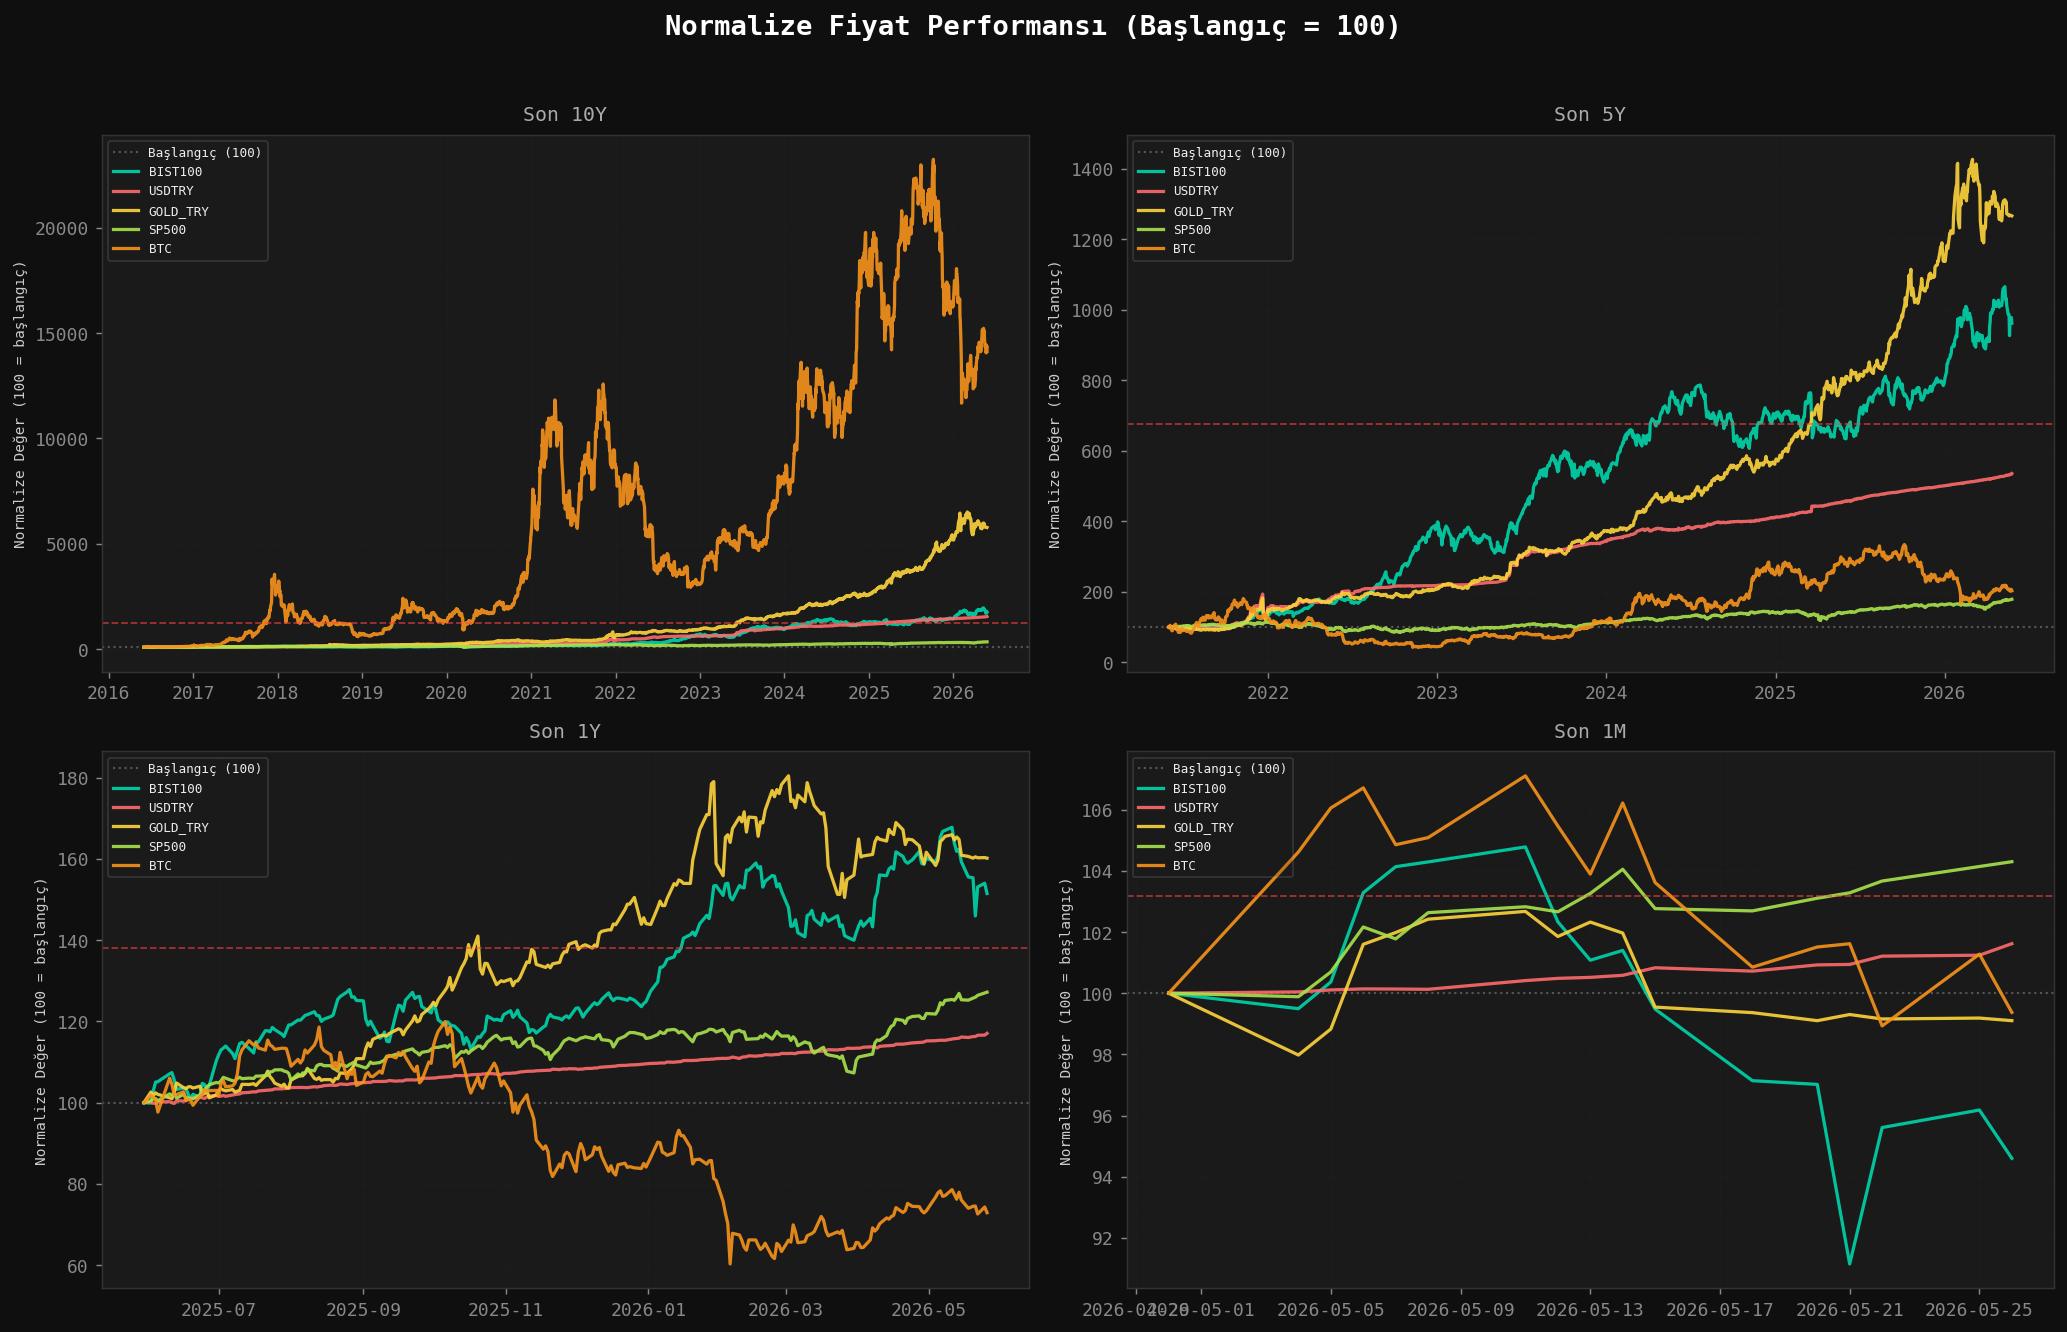

💾 Kaydedildi: normalize_performans.png

💡 Kırmızı kesik çizgi = o dönemin kümülatif enflasyonu
   Bu çizginin üzerindeki araçlar enflasyonu yendi.


In [39]:
# ─────────────────────────────────────────────────────────────────
# GRAFİK 1: NORMALİZE FİYAT GRAFİĞİ
#
# Tüm araçları 100 bazında başlatarak karşılaştır
# Her dönem için ayrı grafik (4 dönem = 4 grafik)
#
# Normalize formülü:
# normalize_fiyat = (fiyat / ilk_fiyat) × 100
# → başlangıç noktası her araç için 100 olur
# → 150 = %50 kazanç, 50 = %50 kayıp
# ─────────────────────────────────────────────────────────────────

grafik_araclari = ['BIST100', 'USDTRY', 'GOLD_TRY', 'SP500', 'BTC']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Normalize Fiyat Performansı (Başlangıç = 100)',
    fontsize=15, fontweight='bold', color='white', y=1.02
)

for ax, donem in zip(axes.flatten(), ['10Y', '5Y', '1Y', '1M']):
    baslangic = DONEMLER[donem]

    # Referans çizgisi: 100 = başlangıç noktası
    ax.axhline(y=100, color='#555555', linestyle=':', linewidth=1.2,
               label='Başlangıç (100)')

    for arac in grafik_araclari:
        if arac not in fiyat_df.columns:
            continue

        # O dönemin verisini al
        seri = fiyat_df[arac][fiyat_df.index >= baslangic].dropna()

        if len(seri) < 2:
            continue

        # Normalize et: ilk değere böl, 100 ile çarp
        normalize = (seri / seri.iloc[0]) * 100

        renk = PALETTE.get(arac, '#888888')

        ax.plot(
            normalize.index,
            normalize.values,
            label=arac,
            color=renk,
            linewidth=1.8,
            alpha=0.9
        )

    # Grafik ayarları
    ax.set_title(f'Son {donem}', color='#aaaaaa', fontsize=11, pad=8)
    ax.set_ylabel('Normalize Değer (100 = başlangıç)', fontsize=8)
    ax.legend(loc='upper left', fontsize=7, framealpha=0.15)
    ax.grid(True, alpha=0.2)

    # Enflasyon çizgisi — sadece görsel referans için
    enf = donem_enflasyon[donem]
    ax.axhline(
        y=100 + enf,
        color='#ff4444',
        linestyle='--',
        linewidth=1,
        alpha=0.6,
        label=f'Enflasyon (+{enf:.0f}%)'
    )

plt.tight_layout()

# Kaydet
plt.savefig(
    'normalize_performans.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f0f'
)

plt.show()
print("💾 Kaydedildi: normalize_performans.png")
print("\n💡 Kırmızı kesik çizgi = o dönemin kümülatif enflasyonu")
print("   Bu çizginin üzerindeki araçlar enflasyonu yendi.")

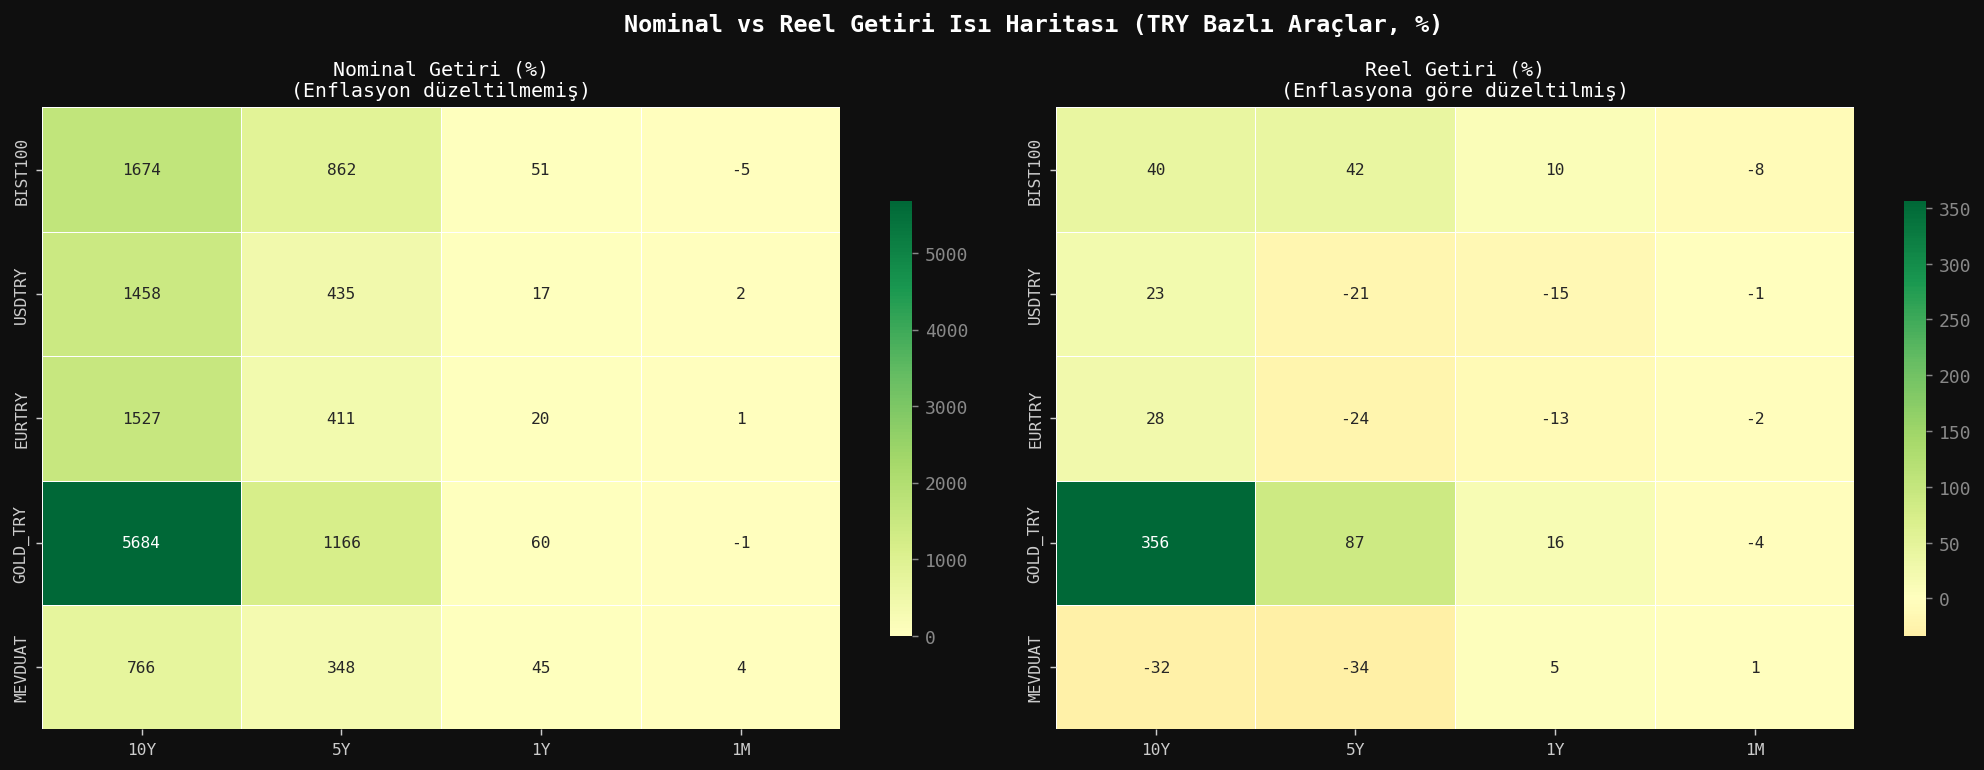

💾 Kaydedildi: isi_haritasi.png

💡 İki haritayı karşılaştır:
   Sol taraf yeşil görünüp sağ taraf kırmızıysa
   → nominal kazanç var ama reel kayıp var demektir.
   Bu Türkiye'nin 2021-2023 mevduat paradoksudur.


In [40]:
# ─────────────────────────────────────────────────────────────────
# GRAFİK 2: ISI HARİTASI — NOMİNAL vs REEL GETİRİ
#
# Isı haritası nedir?
# Sayısal tabloyu renklerle görselleştirir
# Yeşil → yüksek/pozitif getiri
# Kırmızı → düşük/negatif getiri
# Bir bakışta hangi araç hangi dönemde iyi/kötü performans gösterdi?
#
# İki yan yana harita:
# Sol → Nominal getiri (kâğıt üzerindeki rakam)
# Sağ → Reel getiri (enflasyon düzeltilmiş gerçek kazanç)
# ─────────────────────────────────────────────────────────────────

# Gösterilecek araçlar (TRY bazlı — enflasyon karşılaştırması için)
isi_araclari = ['BIST100', 'USDTRY', 'EURTRY', 'GOLD_TRY', 'MEVDUAT']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Nominal vs Reel Getiri Isı Haritası (TRY Bazlı Araçlar, %)',
    fontsize=13, fontweight='bold', color='white'
)

# ── Sol: Nominal Getiri ──────────────────────────────────────────
# .T → tabloyu transpoze et (satır/sütun yer değiştirir)
# Araçlar satırda, dönemler sütunda görünsün
nominal_isi = nominal_df[
    [a for a in isi_araclari if a in nominal_df.columns]
].T

sns.heatmap(
    nominal_isi,
    annot=True,          # her hücreye sayıyı yaz
    fmt='.0f',           # ondalık gösterme, tam sayı
    cmap='RdYlGn',       # kırmızı→sarı→yeşil renk skalası
    center=0,            # 0 = sarı (nötr nokta)
    linewidths=0.5,      # hücre arası çizgi kalınlığı
    ax=ax1,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.7}
)
ax1.set_title('Nominal Getiri (%)\n(Enflasyon düzeltilmemiş)',
              color='white', fontsize=11)
ax1.tick_params(colors='#cccccc', labelsize=9)
ax1.set_xlabel('')
ax1.set_ylabel('')

# ── Sağ: Reel Getiri ────────────────────────────────────────────
reel_isi = reel_df[
    [a for a in isi_araclari if a in reel_df.columns]
].T

sns.heatmap(
    reel_isi,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax2,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.7}
)
ax2.set_title('Reel Getiri (%)\n(Enflasyona göre düzeltilmiş)',
              color='white', fontsize=11)
ax2.tick_params(colors='#cccccc', labelsize=9)
ax2.set_xlabel('')
ax2.set_ylabel('')

plt.tight_layout()

plt.savefig(
    'isi_haritasi.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f0f'
)

plt.show()
print("💾 Kaydedildi: isi_haritasi.png")
print("\n💡 İki haritayı karşılaştır:")
print("   Sol taraf yeşil görünüp sağ taraf kırmızıysa")
print("   → nominal kazanç var ama reel kayıp var demektir.")
print("   Bu Türkiye'nin 2021-2023 mevduat paradoksudur.")

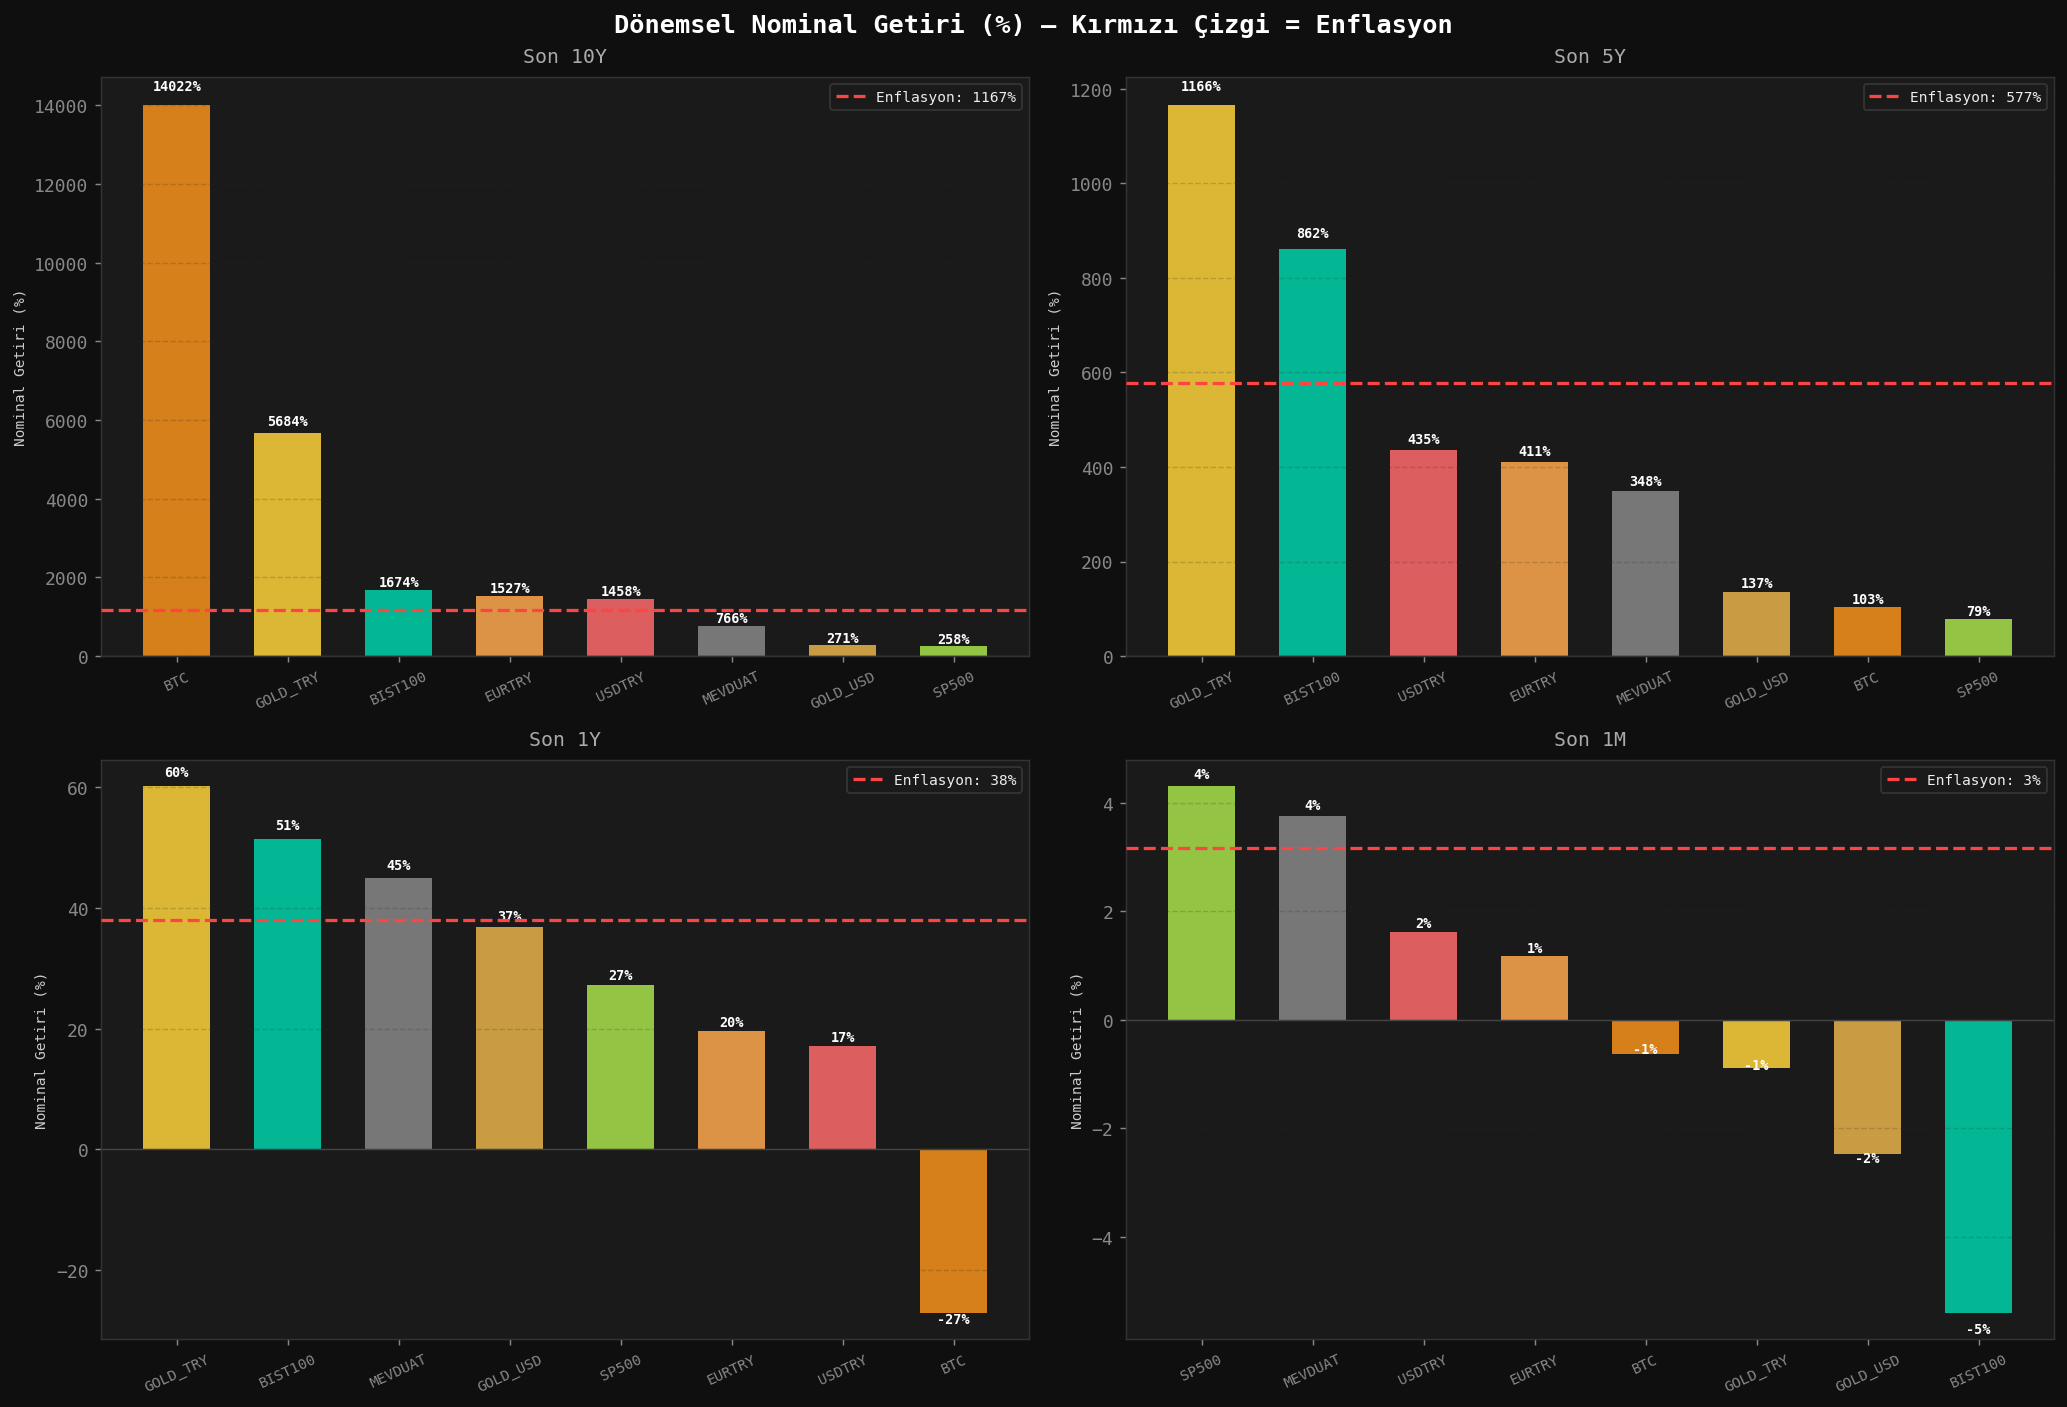

💾 Kaydedildi: bar_grafik.png

💡 Kırmızı çizginin üzerindeki her bar enflasyonu yendi.
   Çizginin altındaki barlar ise nominal kazanç gösterse de
   reel olarak para kaybettirdi.


In [41]:
# ─────────────────────────────────────────────────────────────────
# GRAFİK 3: DÖNEMSel BAR GRAFİKLERİ
#
# Her dönem için tüm araçların nominal getirisini bar olarak göster
# Kırmızı kesik çizgi = o dönemin enflasyonu
# Çizginin üzerindeki barlar → enflasyonu yendi
# Çizginin altındaki barlar → enflasyonu yenemedi
#
# sort_values() → barları büyükten küçüğe sırala
# Bu sayede kazanan araçlar solda, kaybedenler sağda görünür
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Dönemsel Nominal Getiri (%) — Kırmızı Çizgi = Enflasyon',
    fontsize=14, fontweight='bold', color='white'
)

for ax, donem in zip(axes.flatten(), ['10Y', '5Y', '1Y', '1M']):

    # O dönemin verilerini al, boşları çıkar, büyükten küçüğe sırala
    satir = nominal_df.loc[donem].dropna().sort_values(ascending=False)

    # Her bara o araca ait rengi ata
    renkler = [PALETTE.get(arac, '#888888') for arac in satir.index]

    # Barları çiz
    barlar = ax.bar(
        satir.index,
        satir.values,
        color=renkler,
        edgecolor='none',
        width=0.6,
        alpha=0.85
    )

    # Her barın üstüne değeri yaz
    for bar, deger in zip(barlar, satir.values):
        # Pozitif değerler barın üstüne, negatifler altına
        y_pozisyon = bar.get_height() + (abs(bar.get_height()) * 0.02)
        if deger < 0:
            y_pozisyon = bar.get_height() - (abs(bar.get_height()) * 0.08)

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pozisyon,
            f'{deger:.0f}%',
            ha='center',
            va='bottom',
            fontsize=7.5,
            color='white',
            fontweight='bold'
        )

    # Enflasyon referans çizgisi
    enf = donem_enflasyon[donem]
    ax.axhline(
        enf,
        color='#ff4444',
        linestyle='--',
        linewidth=1.8,
        label=f'Enflasyon: {enf:.0f}%',
        zorder=5
    )

    # Sıfır çizgisi
    ax.axhline(0, color='#444444', linewidth=0.8)

    # Grafik ayarları
    ax.set_title(f'Son {donem}', color='#aaaaaa', fontsize=11, pad=8)
    ax.set_ylabel('Nominal Getiri (%)', fontsize=8)
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.legend(fontsize=8, framealpha=0.15)
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()

plt.savefig(
    'bar_grafik.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f0f'
)

plt.show()
print("💾 Kaydedildi: bar_grafik.png")
print("\n💡 Kırmızı çizginin üzerindeki her bar enflasyonu yendi.")
print("   Çizginin altındaki barlar ise nominal kazanç gösterse de")
print("   reel olarak para kaybettirdi.")

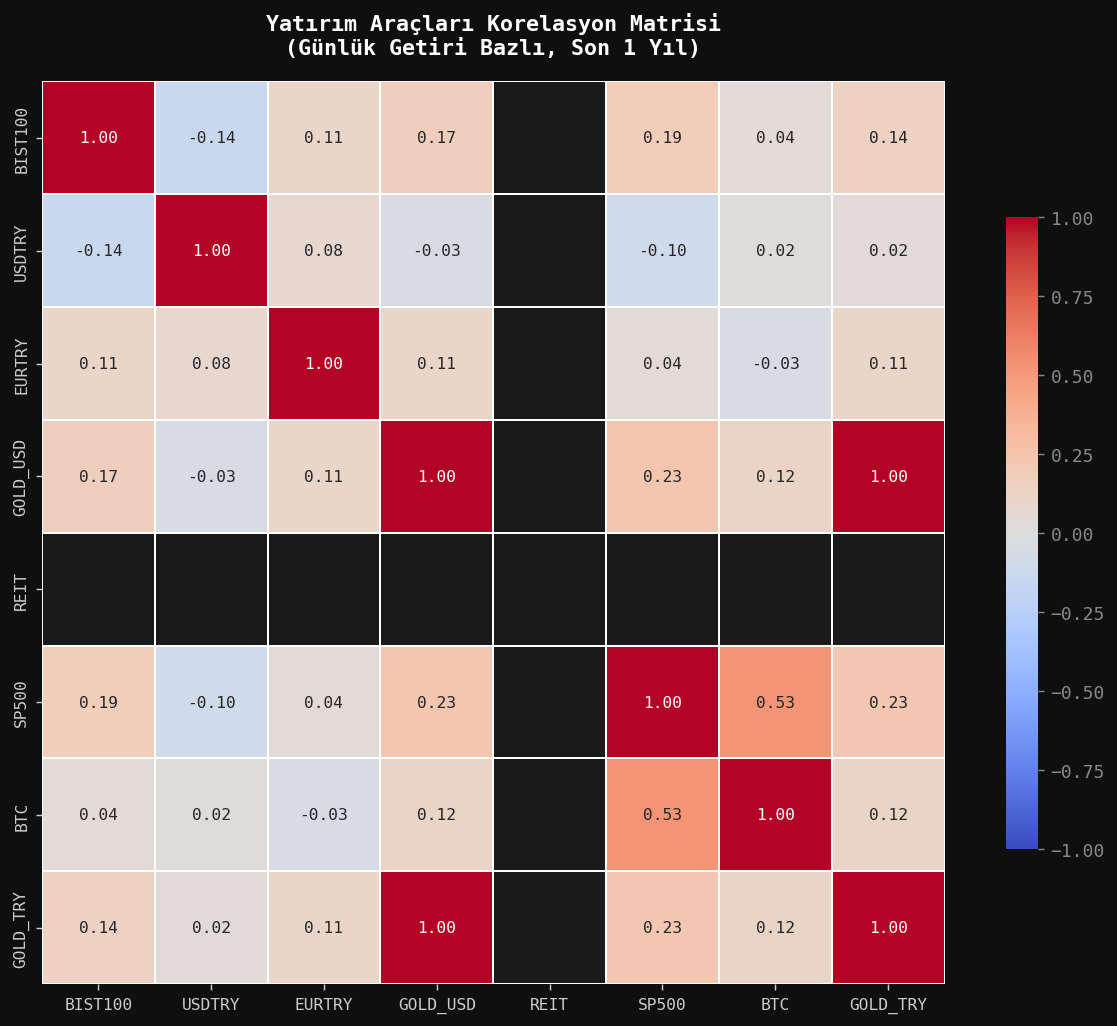

💾 Kaydedildi: korelasyon_matrisi.png

📌 KORELASYON YORUMU:
--------------------------------------------------

   En yüksek korelasyonlu çiftler (birlikte hareket eder):
   GOLD_USD     ↔ GOLD_TRY    : +1.00
   SP500        ↔ BTC         : +0.53
   GOLD_USD     ↔ SP500       : +0.23

   En düşük korelasyonlu çiftler (çeşitlendirme sağlar):
   EURTRY       ↔ BTC         : -0.03
   USDTRY       ↔ GOLD_TRY    : +0.02
   USDTRY       ↔ BTC         : +0.02


In [42]:
# ─────────────────────────────────────────────────────────────────
# GRAFİK 4: KORELASYON MATRİSİ
#
# Korelasyon nedir?
# İki yatırım aracının birlikte hareket etme derecesi
#
# +1.0 → Mükemmel pozitif korelasyon (birlikte yükselir/düşer)
#  0.0 → Korelasyon yok (bağımsız hareket)
# -1.0 → Mükemmel negatif korelasyon (biri yükselirken diğeri düşer)
#
# Neden önemli?
# Portföy çeşitlendirmesi için DÜŞÜK korelasyonlu araçlar seçmek gerekir
# Yüksek korelasyonlu araçları bir arada tutmak çeşitlendirme sağlamaz
#
# Günlük getiri üzerinden hesaplıyoruz:
# pct_change() → her günün bir önceki güne göre % değişimi
# .corr() → tüm sütunlar arası korelasyonu hesaplar
# ─────────────────────────────────────────────────────────────────

# Son 1 yılın verisini al
baslangic_1y = DONEMLER['1Y']
veri_1y = fiyat_df[fiyat_df.index >= baslangic_1y].dropna(how='all')

# Günlük yüzde değişim hesapla
gunluk_getiri = veri_1y.pct_change().dropna(how='all')

# Korelasyon matrisi
korelasyon = gunluk_getiri.corr()

# ─────────────────────────────────────────────────────────────────
# GRAFİĞİ ÇİZ
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    korelasyon,
    annot=True,           # her hücreye korelasyon değerini yaz
    fmt='.2f',            # 2 ondalık basamak göster
    cmap='coolwarm',      # mavi (negatif) → beyaz (0) → kırmızı (pozitif)
    center=0,             # 0 = beyaz/nötr
    vmin=-1, vmax=1,      # renk skalası -1 ile +1 arası
    square=True,          # hücreleri kare yap
    linewidths=1,         # hücre arası çizgi
    ax=ax,
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 9}
)

ax.set_title(
    'Yatırım Araçları Korelasyon Matrisi\n(Günlük Getiri Bazlı, Son 1 Yıl)',
    fontsize=12, fontweight='bold', color='white', pad=15
)
ax.tick_params(colors='#cccccc', labelsize=9)

plt.tight_layout()

plt.savefig(
    'korelasyon_matrisi.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f0f'
)

plt.show()
print("💾 Kaydedildi: korelasyon_matrisi.png")

# ─────────────────────────────────────────────────────────────────
# KORELASYON YORUMU
# ─────────────────────────────────────────────────────────────────

print("\n📌 KORELASYON YORUMU:")
print("-" * 50)

# En yüksek ve en düşük korelasyon çiftlerini bul
ciftler = []
sutunlar = korelasyon.columns.tolist()

for i in range(len(sutunlar)):
    for j in range(i + 1, len(sutunlar)):
        arac1 = sutunlar[i]
        arac2 = sutunlar[j]
        deger = korelasyon.loc[arac1, arac2]
        if not pd.isna(deger):
            ciftler.append((arac1, arac2, deger))

# Korelasyona göre sırala
ciftler.sort(key=lambda x: abs(x[2]), reverse=True)

print("\n   En yüksek korelasyonlu çiftler (birlikte hareket eder):")
for arac1, arac2, deger in ciftler[:3]:
    print(f"   {arac1:12s} ↔ {arac2:12s}: {deger:+.2f}")

print("\n   En düşük korelasyonlu çiftler (çeşitlendirme sağlar):")
for arac1, arac2, deger in ciftler[-3:]:
    print(f"   {arac1:12s} ↔ {arac2:12s}: {deger:+.2f}")

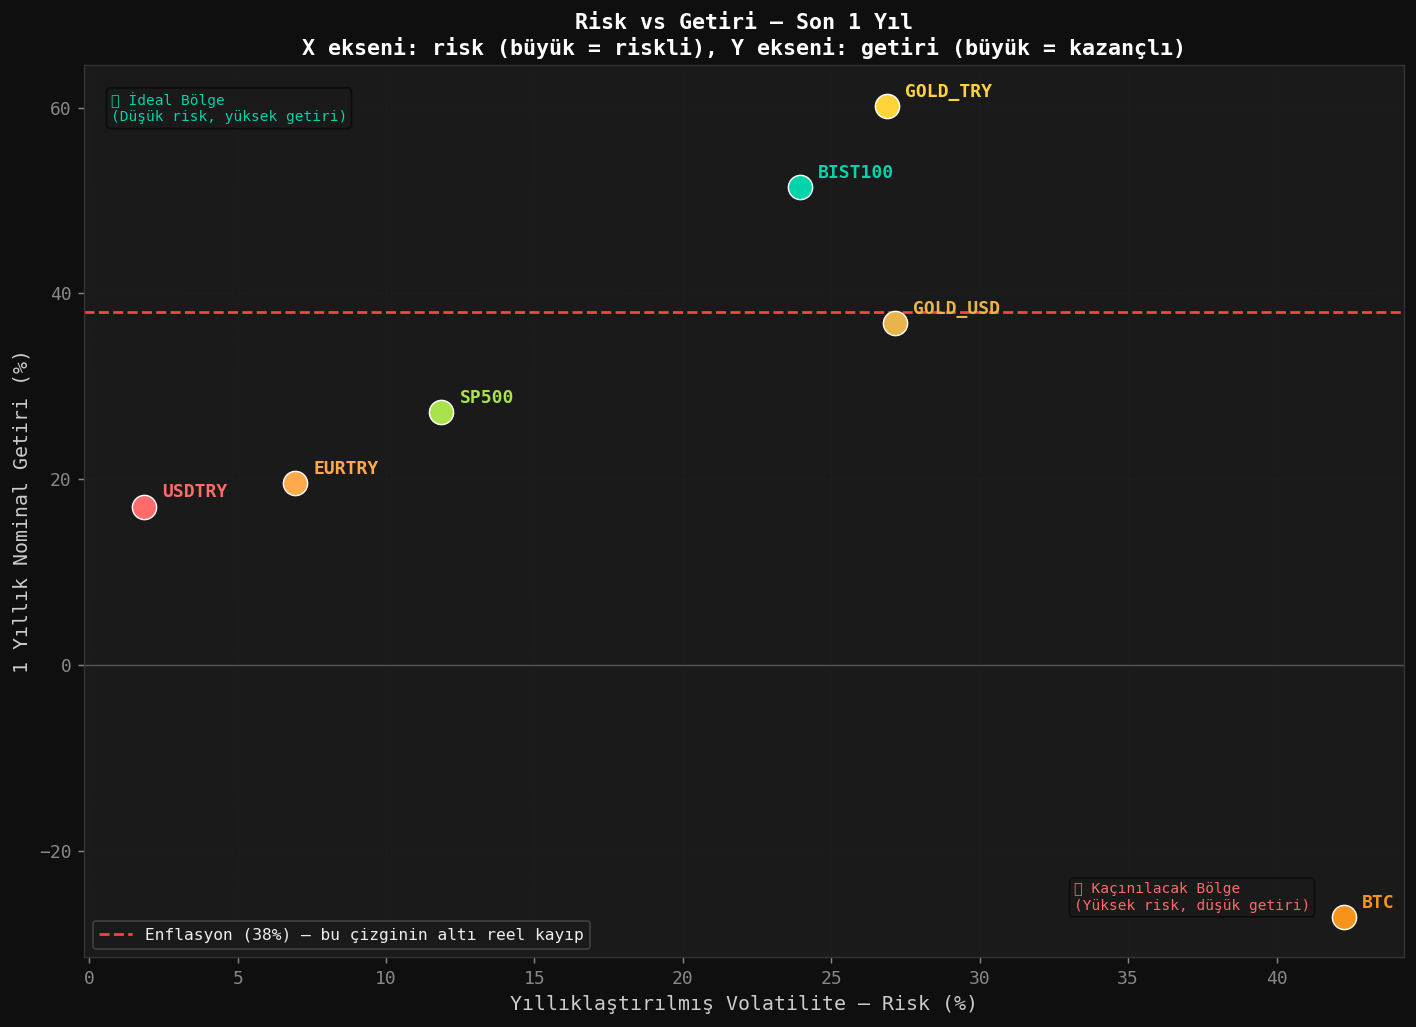

💾 Kaydedildi: risk_getiri_scatter.png

💡 Sol üst köşeye yakın araçlar en iyi risk/getiri dengesini sunar.


In [43]:
# ─────────────────────────────────────────────────────────────────
# GRAFİK 5: RİSK vs GETİRİ SCATTER GRAFİĞİ
# ─────────────────────────────────────────────────────────────────

getiri_1y = nominal_df.loc['1Y'].dropna()
veri_1y = fiyat_df[fiyat_df.index >= DONEMLER['1Y']].copy()
volatilite_1y = veri_1y.pct_change().dropna(how='all').std() * np.sqrt(252) * 100
ortak = getiri_1y.index.intersection(volatilite_1y.index)

fig, ax = plt.subplots(figsize=(11, 8))

for arac in ortak:
    x = volatilite_1y[arac]
    y = getiri_1y[arac]
    renk = PALETTE.get(arac, '#888888')

    ax.scatter(x, y, color=renk, s=180, zorder=5,
               edgecolors='white', linewidth=0.8)

    ax.annotate(arac, (x, y),
                textcoords='offset points',
                xytext=(10, 5),
                fontsize=10, color=renk, fontweight='bold')

# Sıfır çizgisi
ax.axhline(0, color='#555555', linewidth=0.8)

# Enflasyon çizgisi
enf_1y = donem_enflasyon['1Y']
ax.axhline(enf_1y, color='#ff4444', linestyle='--', linewidth=1.5,
           label=f'Enflasyon ({enf_1y:.0f}%) — bu çizginin altı reel kayıp')

# Bölge açıklamaları
ax.text(0.02, 0.97, '✅ İdeal Bölge\n(Düşük risk, yüksek getiri)',
        transform=ax.transAxes, fontsize=8, color='#00d4aa',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', alpha=0.5))

ax.text(0.75, 0.05, '❌ Kaçınılacak Bölge\n(Yüksek risk, düşük getiri)',
        transform=ax.transAxes, fontsize=8, color='#ff6b6b',
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', alpha=0.5))

ax.set_xlabel('Yıllıklaştırılmış Volatilite — Risk (%)', fontsize=11)
ax.set_ylabel('1 Yıllık Nominal Getiri (%)', fontsize=11)
ax.set_title(
    'Risk vs Getiri — Son 1 Yıl\n'
    'X ekseni: risk (büyük = riskli), Y ekseni: getiri (büyük = kazançlı)',
    fontsize=12, fontweight='bold', color='white')
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('risk_getiri_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("💾 Kaydedildi: risk_getiri_scatter.png")
print("\n💡 Sol üst köşeye yakın araçlar en iyi risk/getiri dengesini sunar.")

## 🔍 Bölüm 12: Temel Bulgular ve Yatırım Tavsiyeleri

### Bu bölümde ne yapıyoruz?
Tüm analizden otomatik olarak bulgular üretiyoruz:
- Her dönem en iyi/kötü araç
- Tutarlı enflasyon yenenler
- Sharpe sıralaması

Ardından veriye dayalı tavsiyeler sunuyoruz.

> ⚠️ **Yasal Uyarı:** Bu analiz yalnızca eğitim amaçlıdır.
> Yatırım tavsiyesi değildir. Yatırım kararlarınızı
> lisanslı bir finansal danışmana danışarak alın.

In [44]:
# ─────────────────────────────────────────────────────────────────
# OTOMATİK BULGULAR
#
# Tüm hesapladığımız tablolardan otomatik olarak
# en önemli bulguları çıkarıyoruz
#
# Bu bölüm tamamen veriye dayalı — önyargı yok
# Sayılar ne diyorsa o yazılıyor
# ─────────────────────────────────────────────────────────────────

print("=" * 65)
print("🔍 TEMEL BULGULAR — TÜRKİYE YATIRIM ANALİZİ")
print("=" * 65)

# ── BULGU 1: Her dönem en iyi ve en kötü araç ───────────────────
print("\n📌 BULGU 1: Dönem Bazlı Şampiyon ve Kaybeden")
print("-" * 55)

for donem in ['10Y', '5Y', '1Y', '1M']:
    satir = nominal_df.loc[donem].dropna()
    if len(satir) == 0:
        continue
    en_iyi  = satir.idxmax()
    en_kotu = satir.idxmin()
    print(f"\n  {donem}:")
    print(f"  🥇 En iyi  : {en_iyi:12s} → %{satir[en_iyi]:.0f} nominal getiri")
    print(f"  💀 En kötü : {en_kotu:12s} → %{satir[en_kotu]:.0f} nominal getiri")

# ── BULGU 2: Tutarlı enflasyon yenenler ─────────────────────────
print("\n\n📌 BULGU 2: Tutarlı Enflasyon Yenenler (TRY Araçlar)")
print("-" * 55)
print("  (Kaç dönemde enflasyonu geçti?)\n")

tum_try_araclari = ['BIST100', 'USDTRY', 'EURTRY', 'GOLD_TRY', 'MEVDUAT']

for arac in tum_try_araclari:
    if arac not in nominal_df.columns:
        continue

    yenen = 0
    toplam = 0

    for donem in ['10Y', '5Y', '1Y', '1M']:
        nominal = nominal_df.loc[donem, arac]
        enf     = donem_enflasyon[donem]

        if pd.isna(nominal):
            continue

        toplam += 1
        if nominal > enf:
            yenen += 1

    # Görsel bar
    bar = "█" * yenen + "░" * (toplam - yenen)
    yuzde = yenen / toplam * 100 if toplam > 0 else 0

    isaretci = "✅" if yenen == toplam else ("⚠️ " if yenen > 0 else "❌")
    print(f"  {isaretci} {arac:12s}: {bar} {yenen}/{toplam} dönem  (%{yuzde:.0f})")

# ── BULGU 3: Reel getiri şampiyonu ──────────────────────────────
print("\n\n📌 BULGU 3: Reel Getiri Şampiyonu (10 Yıl)")
print("-" * 55)

reel_10y = reel_df.loc['10Y'].dropna().sort_values(ascending=False)
print()
for arac, deger in reel_10y.items():
    bar_uzunluk = max(0, int(abs(deger) / 20))
    bar = "█" * min(bar_uzunluk, 20)
    isaretci = "✅" if deger > 0 else "❌"
    print(f"  {isaretci} {arac:12s}: {bar} %{deger:.1f}")

# ── BULGU 4: Sharpe şampiyonu ────────────────────────────────────
print("\n\n📌 BULGU 4: En İyi Risk/Getiri Dengesi (Sharpe)")
print("-" * 55)

for donem in ['10Y', '5Y', '1Y']:
    satir = sharpe_df.loc[donem].dropna()
    if len(satir) == 0:
        continue
    en_iyi = satir.idxmax()
    deger  = satir.max()
    yorum  = "Mükemmel" if deger > 1 else ("İyi" if deger > 0.5 else ("Orta" if deger > 0 else "Zayıf"))
    print(f"  {donem}: {en_iyi:12s} → Sharpe={deger:.3f} ({yorum})")

# ── BULGU 5: Mevduatın gerçeği ───────────────────────────────────
print("\n\n📌 BULGU 5: Mevduatın Gerçeği")
print("-" * 55)

negatif = (makro['Reel_Mevduat'] < 0).sum()
pozitif = (makro['Reel_Mevduat'] > 0).sum()
en_kotu_yil = makro['Reel_Mevduat'].idxmin()
en_kotu_deger = makro['Reel_Mevduat'].min()

print(f"\n  Son 11 yılda mevduat:")
print(f"  ✅ {pozitif} yıl enflasyonun önünde kaldı")
print(f"  ❌ {negatif} yıl enflasyonu yenemedi (para eridi)")
print(f"  💀 En kötü yıl: {en_kotu_yil} → reel getiri %{en_kotu_deger:.1f}")
print(f"     (o yıl bankada duran paranın satın alma gücü")
print(f"      %{abs(en_kotu_deger):.1f} eridi)")

print("\n" + "=" * 65)
print("✅ Tüm bulgular veriye dayalı olarak üretildi.")
print("=" * 65)

🔍 TEMEL BULGULAR — TÜRKİYE YATIRIM ANALİZİ

📌 BULGU 1: Dönem Bazlı Şampiyon ve Kaybeden
-------------------------------------------------------

  10Y:
  🥇 En iyi  : BTC          → %14022 nominal getiri
  💀 En kötü : SP500        → %258 nominal getiri

  5Y:
  🥇 En iyi  : GOLD_TRY     → %1166 nominal getiri
  💀 En kötü : SP500        → %79 nominal getiri

  1Y:
  🥇 En iyi  : GOLD_TRY     → %60 nominal getiri
  💀 En kötü : BTC          → %-27 nominal getiri

  1M:
  🥇 En iyi  : SP500        → %4 nominal getiri
  💀 En kötü : BIST100      → %-5 nominal getiri


📌 BULGU 2: Tutarlı Enflasyon Yenenler (TRY Araçlar)
-------------------------------------------------------
  (Kaç dönemde enflasyonu geçti?)

  ⚠️  BIST100     : ███░ 3/4 dönem  (%75)
  ⚠️  USDTRY      : █░░░ 1/4 dönem  (%25)
  ⚠️  EURTRY      : █░░░ 1/4 dönem  (%25)
  ⚠️  GOLD_TRY    : ███░ 3/4 dönem  (%75)
  ⚠️  MEVDUAT     : ██░░ 2/4 dönem  (%50)


📌 BULGU 3: Reel Getiri Şampiyonu (10 Yıl)
--------------------------------------

## 💡 Bölüm 13: Yatırım Tavsiyeleri

> ⚠️ **Yasal Uyarı:** Aşağıdaki tavsiyeler yalnızca bu analizin
> verilerine dayanmaktadır. Kişisel finansal tavsiye değildir.
> Yatırım kararlarınızı lisanslı bir finansal danışmana
> danışarak alın.

---

### 🟢 Veriye Göre Güçlü Araçlar

| Araç | Neden? |
|---|---|
| **Gram Altın** | Her zaman diliminde enflasyonu yendi. En tutarlı reel getiri. En iyi Sharpe oranı. |
| **BIST100** | 5Y ve 10Y'da enflasyonu yendi. Uzun vadeli Türk yatırımcısının en güçlü TRY aracı. |
| **S&P 500** | USD bazında güçlü. TRY değer kaybıyla birleşince Türk yatırımcısına çift kazandırdı. |

### 🟡 Koşullu / Duruma Göre Araçlar

| Araç | Koşul |
|---|---|
| **Mevduat** | Sadece reel faizin pozitif olduğu dönemlerde (2024+) mantıklı. 2021-2023 arası yıkıcıydı. |
| **Dolar/Euro** | Kriz dönemlerinde güvenli liman. Ama uzun vadede tek başına yeterli değil. |
| **Bitcoin** | 10Y'da astronomik getiri ama yıllık volatilite %42. Küçük satellit pozisyon için. |

### 🔴 Dikkat Edilecekler

| Araç | Sorun |
|---|---|
| **Kısa vadeli mevduat** | Enflasyon hâlâ yüksekken kısa vadeli TRY araçlar satın alma gücünü eritiyor. |
| **Nominal getiriye aldanmak** | %50 kazanç güzel görünür ama enflasyon %38 ise reel kazanç sadece %9. |

---

### 📐 Örnek Portföy Dağılımı (Orta Risk Profili)

## 📋 Bölüm 14: Metodoloji ve Kaynaklar

### Veri Kaynakları

| Veri | Kaynak | Erişim Yöntemi |
|---|---|---|
| BIST100, Döviz, Altın, S&P500, BTC | Yahoo Finance | `yfinance` kütüphanesi |
| TÜFE (Enflasyon) | TÜİK | Manuel — resmi yıllık veriler |
| Mevduat Faizi | TCMB | Manuel — politika faizi baz alındı |

---

### Hesaplama Metodolojisi

**Toplam Getiri:**

In [45]:
# ─────────────────────────────────────────────────────────────────
# TÜM GRAFİKLERİ OUTPUTS KLASÖRÜNE TAŞI
#
# os modülü → dosya/klasör işlemleri için
# shutil modülü → dosya kopyalama/taşıma için
# ─────────────────────────────────────────────────────────────────

import os
import shutil

# outputs/ klasörü yoksa oluştur
os.makedirs('outputs', exist_ok=True)

# Taşınacak grafik dosyaları
grafikler = [
    'normalize_performans.png',
    'isi_haritasi.png',
    'bar_grafik.png',
    'korelasyon_matrisi.png',
    'risk_getiri_scatter.png',
]

print("📁 Grafik dosyaları outputs/ klasörüne taşınıyor...\n")

for grafik in grafikler:
    if os.path.exists(grafik):
        shutil.move(grafik, f'outputs/{grafik}')
        print(f"  ✅ {grafik} → outputs/{grafik}")
    else:
        print(f"  ⚠️  {grafik} bulunamadı — ilgili hücreyi çalıştırdın mı?")

# ─────────────────────────────────────────────────────────────────
# PROJE ÖZET RAPORU
# ─────────────────────────────────────────────────────────────────

print("\n")
print("=" * 65)
print("📊 PROJE ÖZET RAPORU")
print("=" * 65)

print(f"""
📅 Analiz tarihi    : {BUGUN.strftime('%d %B %Y')}
📈 Veri aralığı     : {fiyat_df.index[0].strftime('%d %B %Y')} → {fiyat_df.index[-1].strftime('%d %B %Y')}
🗂️  Toplam veri      : {fiyat_df.shape[0]:,} günlük gözlem
📦 Araç sayısı      : {fiyat_df.shape[1]} yatırım aracı
📉 Dönem sayısı     : 4 (1M, 1Y, 5Y, 10Y)
""")

print("─" * 65)
print("🏆 DÖNEM ŞAMPİYONLARI (Nominal Getiri)")
print("─" * 65)
for donem in ['10Y', '5Y', '1Y', '1M']:
    satir = nominal_df.loc[donem].dropna()
    en_iyi = satir.idxmax()
    print(f"  {donem:4s}: {en_iyi:12s} → %{satir[en_iyi]:.0f}")

print("\n" + "─" * 65)
print("💎 REEL GETİRİ ŞAMPİYONU (10 Yıl, Enflasyon Düzeltilmiş)")
print("─" * 65)
reel_10y = reel_df.loc['10Y'].dropna().sort_values(ascending=False)
for arac, deger in reel_10y.head(3).items():
    isaretci = "✅" if deger > 0 else "❌"
    print(f"  {isaretci} {arac:12s}: %{deger:.1f}")

print("\n" + "─" * 65)
print("⚠️  KRİTİK BULGU")
print("─" * 65)
nom_mevduat_10y = nominal_df.loc['10Y', 'MEVDUAT']
reel_mevduat_10y = reel_df.loc['10Y', 'MEVDUAT']
print(f"""
  Mevduat 10Y nominal getiri  : %{nom_mevduat_10y:.0f}
  10Y kümülatif enflasyon     : %{donem_enflasyon['10Y']:.0f}
  Mevduat 10Y reel getiri     : %{reel_mevduat_10y:.1f}

  → "Güvenli" zannettiğin mevduat 10 yılda
    satın alma gücünün %{abs(reel_mevduat_10y):.0f}'ini eritti.
""")

print("=" * 65)
print("✅ Analiz tamamlandı! Grafikler outputs/ klasöründe.")
print("=" * 65)

📁 Grafik dosyaları outputs/ klasörüne taşınıyor...

  ✅ normalize_performans.png → outputs/normalize_performans.png
  ✅ isi_haritasi.png → outputs/isi_haritasi.png
  ✅ bar_grafik.png → outputs/bar_grafik.png
  ✅ korelasyon_matrisi.png → outputs/korelasyon_matrisi.png
  ✅ risk_getiri_scatter.png → outputs/risk_getiri_scatter.png


📊 PROJE ÖZET RAPORU

📅 Analiz tarihi    : 29 May 2026
📈 Veri aralığı     : 31 May 2016 → 26 May 2026
🗂️  Toplam veri      : 2,493 günlük gözlem
📦 Araç sayısı      : 8 yatırım aracı
📉 Dönem sayısı     : 4 (1M, 1Y, 5Y, 10Y)

─────────────────────────────────────────────────────────────────
🏆 DÖNEM ŞAMPİYONLARI (Nominal Getiri)
─────────────────────────────────────────────────────────────────
  10Y : BTC          → %14022
  5Y  : GOLD_TRY     → %1166
  1Y  : GOLD_TRY     → %60
  1M  : SP500        → %4

─────────────────────────────────────────────────────────────────
💎 REEL GETİRİ ŞAMPİYONU (10 Yıl, Enflasyon Düzeltilmiş)
────────────────────────────────────────